<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">From someone else's figure to your own analysis</h3>
<p align="center"><b>SOLUTIONS</b> &mdash; worked on the Visual Learning dataset</p>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

This morning you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel, along
with the dataset it came from &mdash; ideally one you did *not* work on this morning.

| Part | Task |
| --- | --- |
| 1 | Load their dataset and find the pieces the figure needs |
| 2 | Reproduce the figure, and interrogate what it shows |
| 3 | Align activity to event onsets: raster and PSTH |
| 4 | Signal and noise correlations, and whether to trust them |

You already have the data-access skills for Part 1 from this morning's tutorial. This problem set is
about what comes after loading: **shaping data, and checking whether the result means anything.**

**Deliverable:** a short README naming the figure and dataset you chose, the decisions you made at
each step, and an honest assessment of what your numbers do and do not support.

<b>Every dataset is different, and the notebook does not know which one you picked.</b> The code
cells are prompts, not templates &mdash; you write what goes in them, using the access patterns from
this morning. Only a few things are given: the imports, and two helper functions from the tutorial.

The differences you will run into are not cosmetic. Across the datasets in this workshop:

- **Recording modality** &mdash; a continuous calcium signal in some, discrete spike times in
  others. Spikes need binning before anything here applies.
- **Sampling rate** &mdash; from a few Hz to tens of kHz, which sets what timing you can resolve.
- **Number of neurons** &mdash; tens to thousands, which changes what is tractable in one pass.
- **Stimulus structure** &mdash; many conditions with few repeats, few conditions with many, or no
  sensory stimulus at all.
- **What was recorded alongside** &mdash; running, licking, pupil, reward; some datasets have all of
  it, some none.
- **Where things live in the file** &mdash; container and column names differ, and so does which
  container holds the trial table.

None of that is written on the outside of the file. **You have to look.** Part of each prompt is
deciding whether the analysis it asks for even applies to your dataset &mdash; and saying so when it
does not.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

You can now generate an analysis faster than you can check one. Ask an LLM for a correlation matrix
and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

So the questions to keep asking are:

- **What is actually in this file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?**
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as this morning: find your dataset's mount under <code>/data</code>, locate a
session's NWB file, then dot and bracket notation into the containers.

**Your classmate's figure tells you what to look for.** Before you open anything, list the pieces the
figure needs &mdash; neural activity, plus whatever else it plots: a behavioral trace, epoch
boundaries, trial times, stimulus identity.

Then find each one, and note the ones that turn out not to exist. **A piece being absent is a
finding about the dataset, not a failure.** Some datasets have no running wheel, no pupil camera, no
visual stimulus at all. You will build the figure from what is there.

</div>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

data_dir = '/data'

In [2]:
# Each dataset attached to this capsule appears as its own directory under /data.
for mount in sorted(os.listdir(data_dir)):
    print(mount)

409828_V1DD_Filtered
416296_V1DD_Filtered
427836_V1DD_Filtered
438833_V1DD_Filtered
Neuropixels_Opto_ecephys_nwb_combined
Visual-Learning-SWDB
brain-computer-interface-v2
dynamicrouting_datacube
metadata


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Start from the metadata table, not the file tree.</b> Each dataset has a metadata CSV in
<code>/code/metadata/</code> &mdash; one row per session, with subject, session type, date and the
asset name. Read that first and choose a session from it, because the filename alone will not tell you
which imaging stage or task condition you are looking at.

Then build the path: the NWB lives inside that dataset's mount under <code>/data/</code>.

</div>

In [3]:
# EDIT: the metadata table for your dataset
metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'visual_learning_session_metadata.csv'))

print(metadata.shape)
print(metadata.columns.tolist())
metadata.head()

(147, 25)
['subject_id', 'session_id', 'name', 'session_type', 'acquisition_type', 'stage', 'image_set', 'session_number', 'acquisition_date', 'session_date', 'session_time', 'age_days', 'genotype', 'sex', 'date_of_birth', 'rig', 'project_name', 'n_planes', 'plane_names', 'imaging_depths', 'targeted_structures', 'processed_stamp', '_id', 'in_capsule', 'planes_failing_zdrift']


,subject_id,session_id,name,session_type,acquisition_type,stage,image_set,session_number,acquisition_date,session_date,session_time,age_days,genotype,sex,date_of_birth,rig,project_name,n_planes,plane_names,imaging_depths,targeted_structures,processed_stamp,_id,in_capsule,planes_failing_zdrift
0,782149,multiplane-ophys_782149_2025-03-25_09-46-08,multiplane-ophys_782149_2025-03-25_09-46-08_pr...,TRAINING_0_gratings_autorewards_15min,TRAINING_0_gratings_autorewards_15min,TRAINING_0,NaN,1,2025-03-25,2025-03-25,09:46:08.591468,108,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,422_MESO2_20241017,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[40, 320, 80, 280, 120, 240, 160, 200]",['VISp'],2026-08-19_00-32-51,aca6e6d2-9f33-4ed6-8a66-86d69a282c30,True,0.0
1,782149,multiplane-ophys_782149_2025-03-28_10-55-25,multiplane-ophys_782149_2025-03-28_10-55-25_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,2,2025-03-28,2025-03-28,10:55:25.569080,111,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 114, 244, 80, 280, 40, 310]",['VISp'],2026-08-19_00-34-09,2a3f8254-9f86-42fd-b4d7-fe1877ebf959,True,0.0
2,782149,multiplane-ophys_782149_2025-03-29_10-10-29,multiplane-ophys_782149_2025-03-29_10-10-29_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,3,2025-03-29,2025-03-29,10:10:29.493070,112,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,Learning mFISH-V1omFISH,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[158, 198, 114, 246, 80, 276, 43, 306]",['VISp'],2026-08-19_00-33-54,7591b588-f6a1-474d-b00a-3dd10ffb4a60,True,3.0
3,782149,multiplane-ophys_782149_2025-03-31_12-23-33,multiplane-ophys_782149_2025-03-31_12-23-33_pr...,TRAINING_1_gratings,TRAINING_1_gratings,TRAINING_1,NaN,4,2025-03-31,2025-03-31,12:23:33.753970,114,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 115, 245, 80, 280, 40, 310]",['VISp'],2026-08-19_00-34-28,d00bf70e-41c7-4ec5-ac76-8aecb010fbe1,True,0.0
4,782149,multiplane-ophys_782149_2025-04-01_09-42-11,multiplane-ophys_782149_2025-04-01_09-42-11_pr...,TRAINING_2_gratings_flashed,TRAINING_2_gratings_flashed,TRAINING_2,NaN,5,2025-04-01,2025-04-01,09:42:11.814685,115,Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-IC...,Male,2024-12-07,429_MESO1_20241016,LearningmFISHTask1A,8,"['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp...","[160, 200, 115, 240, 85, 280, 40, 300]",['VISp'],2026-08-19_00-33-58,ac0f8e4d-cd12-453a-8d83-6b7951a6a957,True,2.0


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Which session does your classmate's figure come from? Use the table to find it
&mdash; subject, session type, date &mdash; and say what you filtered on.

Look at what the table offers before you filter. How many subjects, how many session types, how many
sessions each? That inventory is the first thing you know about the dataset.

**Then ask what kind of neurons you are recording from.** This is not a detail &mdash; it decides
what your population average means. Check the transgenic line, the virus, and any other metadata
describing what was labeled (`nwb.subject.genotype`, the imaging plane's `indicator`, the session
metadata table).

- **Imaging.** You see only the cells expressing the calcium indicator. A pan-excitatory driver
  gives you a very different population from an interneuron-specific one, and "population activity"
  in each case means something different.
- **Electrophysiology.** A probe records whatever is near it, so the recording is not cell-type
  specific by default. But a line or virus may still be present for **optotagging** &mdash; light
  activation used to identify a targeted cell type among the recorded units. If so, there may be a
  column marking which units were tagged.

Write down what is labeled in your session, and say what population your averages are actually
averaging over.

</div>

In [55]:
# EDIT: choose a session from the metadata table.
# Filter on whatever identifies your figure's session, then take one row.
print(metadata.session_type.value_counts().to_string())

candidates = metadata[metadata.session_type == 'OPHYS_4_images_B']
print(f'\n{len(candidates)} sessions of this type')

# The metadata table carries QC and availability flags -- use them before
# picking a session. `in_capsule` says the NWB file is actually mounted here,
# and `planes_failing_zdrift` counts planes that failed the z-drift check
# (NaN means the session has no QC record at all, which is not the same as passing).
available = candidates[candidates.in_capsule
                       & (candidates.planes_failing_zdrift == 0)]
print(f'{len(available)} of those are in this capsule with all planes passing z-drift QC')
if len(available):
    candidates = available

session = candidates.iloc[0]

# Print whichever identifying columns this table actually has.
show = [c for c in ['subject_id', 'session_id', 'session_type', 'acquisition_date', 'genotype',
                    'n_planes', 'targeted_structures', 'planes_failing_zdrift']
        if c in candidates.columns]
print()
print(session[show].to_string())


session_type
TRAINING_1_gratings                      26
TRAINING_3_images_A_10uL_reward          19
STAGE_1                                  19
OPHYS_6_images_B                         15
OPHYS_1_images_A                         12
OPHYS_4_images_B                         12
TRAINING_2_gratings_flashed               9
TRAINING_4_images_A_training              7
TRAINING_0_gratings_autorewards_15min     7
TRAINING_5_images_A_epilogue              7
STAGE_0                                   7
TRAINING_5_images_A_handoff_ready         6
TRAINING_5_images_A_handoff_lapsed        1

12 sessions of this type
8 of those are in this capsule with all planes passing z-drift QC

subject_id                                                          782149
session_id                     multiplane-ophys_782149_2025-04-28_10-02-28
session_type                                              OPHYS_4_images_B
acquisition_date                                                2025-04-28
genotype              

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Now build the path.</b> An NWB file is either a single <code>.nwb</code> file (HDF5) or a
<code>.nwb.zarr</code> <i>directory</i>, and datasets here are packaged by different groups &mdash; the
file may sit at the top of the mount or a few levels down. Search for it rather than hardcoding a
path, and check you got exactly one match.

</div>

In [5]:
# EDIT: the mount holding your dataset -- one of the names listed above.
dataset_dir = os.path.join(data_dir, 'Visual-Learning-SWDB')
session_dir = os.path.join(dataset_dir, session['name'])

# One session directory holds one NWB store. Match on 'nwb' in the name to catch
# both forms -- a .nwb file and a zarr directory -- but exclude sidecar files:
# assets often ship an 'nwb_contents.json' next to the store itself.
nwb_file = [path for path in os.listdir(session_dir)
            if 'nwb' in path and not path.endswith('.json')]
print(len(nwb_file), 'nwb file(s) detected:', nwb_file)

assert len(nwb_file) == 1, f'expected one NWB store, found {len(nwb_file)}'
nwb_path = os.path.join(session_dir, nwb_file[0])
print(nwb_path)


1 nwb file(s) detected: ['multiplane-ophys_782149_2025-04-28_10-02-28.nwb.zarr']
/data/Visual-Learning-SWDB/multiplane-ophys_782149_2025-04-28_10-02-28_processed_2026-08-19_00-34-43/multiplane-ophys_782149_2025-04-28_10-02-28.nwb.zarr


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Did you get exactly one match? More than one usually means several processing
generations of the same session are attached &mdash; check which you picked. Zero means the session
in the table is not mounted in this capsule, which is worth knowing before you debug anything else.

</div>

In [6]:
# Which physical form is it? This decides the backend, and what tells you is
# whether the path is a FILE or a DIRECTORY -- not the name:
#   a FILE      -> HDF5, read by pynwb.NWBHDF5IO
#   a DIRECTORY -> a zarr store, read by hdmf_zarr.NWBZarrIO
# Do not test for a '.zarr' suffix. Some assets name the store after the
# session with no suffix at all, and it is still zarr.
# pynwb.read_nwb inspects the path and picks the right backend, so the same
# call works for both. hdmf_zarr must be installed for the zarr case, but you
# never import it yourself.
print('zarr store (directory)' if os.path.isdir(nwb_path) else 'HDF5 file')

nwb = pynwb.read_nwb(nwb_path)
print(type(nwb).__name__)

# What kind of neurons is this? The genotype names the driver line and the
# indicator; for imaging, the imaging plane repeats the indicator directly.
print('genotype :', nwb.subject.genotype)
print('species  :', nwb.subject.species, '| sex:', nwb.subject.sex)

if nwb.imaging_planes:
    first_plane = list(nwb.imaging_planes.values())[0]
    print('indicator:', first_plane.indicator)
    print('location :', first_plane.location)

# For probe data the recording is not cell-type specific, but an optotagging
# line or virus may let you identify targeted units. Look for a column saying so.
if nwb.units is not None:
    tagging_columns = [column for column in nwb.units.colnames
                       if any(word in column.lower() for word in ('opto', 'tag', 'cell_type'))]
    print('optotagging columns in units:', tagging_columns or 'none')


zarr store (directory)


/opt/conda/lib/python3.12/site-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for TimestampVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/opt/conda/lib/python3.12/site-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for DurationVectorData than the existing definition from nwb.event.yaml. Defaulting to the existing specification from nwb.event.yaml, but compatibility issues may be present. Please update the extension version if possible.
  self.register_spec(spec, source_file)
/opt/conda/lib/python3.12/site-packages/hdmf/spec/catalog.py:101: UserWarning: ndx-events defines a different specification for MeaningsTable than the existing definition from table.yaml. Defaulting to the existing specif

NdxEventsNWBFile
genotype : Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-ICL-IRES-tTA2)/wt
species  : Mus musculus | sex: M
indicator: Slc32a1-IRES-Cre/wt;Oi1(TIT2L-jGCaMP8s-WPRE-ICL-IRES-tTA2)/wt
location : Structure: VISp Depth: 160


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the data the figure needs</h3>

A handful of containers hold almost everything. Which one holds what **varies by dataset**, so list
them all before you index into any of them.

| container | commonly holds |
| --- | --- |
| `processing` | processed neural activity &mdash; in some datasets also behavior |
| `intervals` | epoch tables, trial tables, stimulus presentation tables |
| `stimulus` | stimulus templates &mdash; but in some datasets, the trial tables too |
| `acquisition` | raw acquired signals |
| `events` | discrete behavioral and stimulus events, in some datasets |

Row three is not hypothetical: some datasets put their trial tables in `stimulus` and leave
`intervals` holding only epochs. If you look in one container, find nothing, and conclude the data
is missing, you will be wrong. **Print them all.**

The `events` row needs its own warning. It is optional &mdash; plenty of files do not have one, and
`nwb.processing` will not reveal it either way, because it is reached by its own accessor
(`nwb.events`, or `nwb.get_all_events()` for a single table across all event types). When it *is*
present it holds **behavioral and stimulus events** &mdash; licks, rewards, stimulus changes &mdash;
each a timestamped row with an `event_type` column. It does **not** hold neural events. Where a file
has no events table, the same information is usually in a `processing` behavior module or implicit
in columns of the trials table.

<h3>&ldquo;Events&rdquo; means two different things</h3>

The word is overloaded in NWB, and the two meanings live in different places.

<b>1. Neural events &mdash; inside a `processing` plane.</b> A plane usually holds several
representations of the same neurons: raw fluorescence, neuropil-corrected, dF/F, and often events.
Events are the output of running <b>deconvolution</b> on dF/F &mdash; an attempt to recover the
discrete firing that produced the slow calcium signal. Stored as an array with the <i>same shape and
same timestamps</i> as dF/F, but <b>mostly zeros</b>: nonzero only where an event was detected, the
value carrying its inferred magnitude. Treat the nonzero samples as spike-like events, not as a
continuous trace. The name is not standardised &mdash; one dataset calls it <code>events</code>,
another <code>event_timeseries</code>, and some have none at all and give you only dF/F.

<b>2. Behavioral / task events &mdash; a separate table.</b> Discrete, timestamped occurrences during
the session: licks, rewards, stimulus changes. These may sit in an events table reached through
`nwb.events` or `nwb.get_all_events()`, in a `processing` behavior module, or be implicit in columns
of the trials table. Unlike neural events, these are <b>measured, not inferred</b>.

A container is not always visible from the top level, so print the interfaces inside each processing
module too &mdash; and remember `nwb.processing` will not show you an events table reached by its own
accessor.

</div>


In [7]:
# What is in this file? Look before you index.
print('processing :', list(nwb.processing.keys()))
print('intervals  :', list(nwb.intervals.keys()) if nwb.intervals else [])
print('acquisition:', list(nwb.acquisition.keys()))
print('stimulus   :', list(nwb.stimulus.keys()) if nwb.stimulus else [])

# A processing module is itself a container. Look inside each one -- this is where
# the different representations of the neural signal live (raw, dff, events, ...).
for module_name in nwb.processing:
    print(f'\nprocessing[{module_name!r}]:',
          list(nwb.processing[module_name].data_interfaces))

# Behavioral events may be reached by their own accessor rather than appearing in
# any of the four containers above. Not every file has them.
if getattr(nwb, 'events', None):
    behavior_events = nwb.get_all_events()
    print('\nnwb.get_all_events():', behavior_events.shape)
    print(behavior_events.event_type.value_counts().to_string())
else:
    print('\nno events table in this file')


processing : ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7', 'running']
intervals  : ['intervals', 'natural_movie_one_presentations', 'stimulus_presentations', 'trials']
acquisition: ['v_in', 'v_sig']
stimulus   : []

processing['VISp_0']: ['dff_timeseries', 'event_timeseries', 'image_segmentation', 'images', 'neuropil_corrected_timeseries', 'neuropil_fluorescence_timeseries', 'raw_timeseries']

processing['VISp_1']: ['dff_timeseries', 'event_timeseries', 'image_segmentation', 'images', 'neuropil_corrected_timeseries', 'neuropil_fluorescence_timeseries', 'raw_timeseries']

processing['VISp_2']: ['dff_timeseries', 'event_timeseries', 'image_segmentation', 'images', 'neuropil_corrected_timeseries', 'neuropil_fluorescence_timeseries', 'raw_timeseries']

processing['VISp_3']: ['dff_timeseries', 'event_timeseries', 'image_segmentation', 'images', 'neuropil_corrected_timeseries', 'neuropil_fluorescence_timeseries', 'raw_timeseries']

processing['VISp_4']: ['d

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Our example session puts 8 imaging planes plus a running-speed interface in `processing`,
and three tables in `intervals`: `stimulus_presentations`, `trials`, and a general-purpose
`intervals` table. `acquisition` and `stimulus` are effectively empty here.

**Where a piece lives is not fixed** &mdash; some datasets put trial tables in `stimulus` rather than
`intervals`, and a name you expect in one container may sit in another. And **an empty container
means "not here", not "does not exist"**: had we seen `intervals: []` and concluded the session had
no stimulus information, we would have been wrong even though the printout was accurate.

Both senses of "events" appear in this file, which is why it is worth separating them.

**Neural events.** Each plane offers `raw_timeseries`, `neuropil_corrected_timeseries`,
`dff_timeseries` and `event_timeseries` &mdash; four representations of the same neurons. The event
array has the same shape and timestamps as dF/F but is **89.7% zeros**, against 0% for dF/F. That
sparsity is the deconvolution: it is claiming activity happened at particular samples and nowhere
else.

**Behavioral events.** Reached by `nwb.get_all_events()`, not visible in any of the four containers:
2800 rows, timestamped, with an `event_type` column &mdash; 2266 licks, 224 image changes, 190 image
omissions, 120 rewards. Had we printed only the four containers and stopped, we would have concluded
this session recorded no licking.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your dataset continuous or spiking?</b> This is the first fork in the road, and it
changes what "activity" even means.

<b>Continuous</b> (calcium imaging, LFP): a `(n_timepoints, n_cells)` array already exists in the
file. Find it and you are done.

<b>Spiking</b> (Neuropixels, sorted electrophysiology): there is no such array. Each unit carries its
own list of spike times, usually in a `units` table, and you must <b>bin</b> them yourself &mdash;
choose a bin width, count spikes per bin, divide by the width to get a rate in spikes/s. Everything
downstream then works the same way.

Two decisions come with spiking data, and neither has a default:

- <b>Which units.</b> Spike sorting produces more units than you should analyze. There will be
  quality-control columns (`is_qc_pass`, `firing_rate`, `presence_ratio`, `snr`) and often an
  anatomical label. Select on them explicitly and say what you selected &mdash; a session can drop
  from thousands of units to dozens, and the ones you drop change your answer.
- <b>Bin width.</b> Too wide blurs the response; too narrow leaves mostly-empty bins and noisy
  single-trial estimates. Try a few and see how much your answer moves.

<pre>
bin_width = 0.010                                    # seconds -- your decision
edges = np.arange(0, t_end + bin_width, bin_width)
counts, _ = np.histogram(one_unit_spike_times, bins=edges)
rate = counts / bin_width                            # spikes/s
bin_centres = edges[:-1] + bin_width / 2
</pre>

Sparse binned spikes behave like a deconvolved calcium trace: sharper in time, and noisy per
trial.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Two things to check as you pull out the activity trace.</b>

<b>Timestamps.</b> Some datasets store an explicit `timestamps` array; others store a sampling
`rate` and a `starting_time`, and you reconstruct the times yourself. Everything downstream needs
real times in seconds, so check which you have &mdash; `series.timestamps` is `None` when the file
uses a rate.

<b>Lazy loading.</b> NWB data objects do not load until you index them. That is what lets you open a
50&nbsp;GB file instantly, but it means `data.std()` may fail where `np.std(data)` works. Convert
with `np.asarray()` once you know the array is small enough to hold, or slice first.

</div>

In [8]:
# Neural activity: dF/F for one plane
plane = 'VISp_0'
dff_series = nwb.processing[plane]['dff_timeseries']['dff_timeseries']

dff = dff_series.data[:]

# EDIT: some datasets store a rate instead of a timestamps array
if dff_series.timestamps is not None:
    ts = dff_series.timestamps[:]
else:
    ts = np.arange(dff.shape[0]) / dff_series.rate + dff_series.starting_time
    print(f'no timestamps array; reconstructed from rate = {dff_series.rate:.2f} Hz')

print('dff shape (nframes, nrois):', np.shape(dff))
print('timestamps shape:', np.shape(ts))
print(f'frame rate: {1 / np.median(np.diff(ts)):.2f} Hz')
print(f'session duration: {ts[-1] / 60:.1f} min')

dff shape (nframes, nrois): (42721, 80)
timestamps shape: (42721,)
frame rate: 9.48 Hz
session duration: 75.4 min


In [9]:
# Behavior and stimulus tables -- same file, same clock.
# Tables become DataFrames with .to_dataframe(); timeseries have .data and .timestamps.
stimulus_table = nwb.intervals['stimulus_presentations'].to_dataframe()
trials = nwb.intervals['trials'].to_dataframe()

speed_series = nwb.processing['running']['speed']
running_speed = speed_series.data[:]
running_ts = speed_series.timestamps[:]

print('stimulus_table:', stimulus_table.shape)
print('trials:       ', trials.shape)
print('running_speed:', running_speed.shape)

stimulus_table: (4805, 13)
trials:        (767, 27)
running_speed: (270200,)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Quality control: which cells or units belong in the analysis?</h3>

Segmentation and spike sorting are automated, and both over-produce. An ophys plane contains ROIs the
classifier thinks are not cell bodies; a sorted probe contains units that drift, that are barely
above noise, or that are two neurons merged. <b>The activity matrix you just loaded usually contains
all of them.</b>

Pipelines record their own verdicts. For imaging they live on the ROI table beside the masks; for
electrophysiology, on the units table. The columns differ by pipeline and by dataset &mdash; boolean
flags, continuous probabilities, morphology metrics, contamination estimates &mdash; so there is no
list to memorise. Print the columns and see what your dataset offers.

Filtering is not automatically the right move, and the criteria are yours to justify. But
<b>inheriting the unfiltered set by default is a decision you made without noticing</b>, and it is the
kind that never appears in a methods section.

</div>

In [10]:
# EDIT: where the per-cell QC table lives in your dataset.
# Imaging: usually a plane segmentation beside the masks.
# Electrophysiology: usually nwb.units.
segmentation = nwb.processing[plane]['image_segmentation']
print('tables available:', list(segmentation.plane_segmentations.keys()))

roi_table = segmentation.plane_segmentations['roi_table'].to_dataframe()
print('roi_table:', roi_table.shape)

# Mask/image columns are big; look at the scalar ones.
scalar = [c for c in roi_table.columns
          if roi_table[c].dtype != object or roi_table[c].dtype == bool]
print('\nscalar columns:')
for c in scalar:
    v = roi_table[c]
    if not pd.api.types.is_numeric_dtype(v) and v.dtype != bool:
        print(f'  {c:28s} {str(v.dtype):8s} (non-numeric)')
        continue
    # A flag can arrive as bool OR as int64 0/1 -- test the values, not the dtype.
    if set(np.unique(v)) <= {0, 1, True, False}:
        print(f'  {c:28s} flag     {int(v.sum())} True / {len(v)}')
    else:
        print(f'  {c:28s} {str(v.dtype):8s} min {v.min():.3g}  median {v.median():.3g}  max {v.max():.3g}')

tables available: ['neuropil_table', 'roi_table']
roi_table: (80, 11)

scalar columns:
  is_soma                      flag     77 True / 80
  soma_probability             float32  min 0.0322  median 1  max 1
  is_dendrite                  flag     2 True / 80
  dendrite_probability         float32  min 0  median 5.07e-07  max 0.971
  cellpose_soma_probability    float32  min 0.558  median 0.861  max 0.904
  aspect_ratio                 float32  min 0.999  median 1.11  max 1.38
  compact                      float32  min 1  median 1.02  max 1.14
  solidity                     float32  min 0.967  median 1.09  max 1.18
  radius                       float32  min 5.58  median 8.4  max 13.6
  footprint                    flag     80 True / 80


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Does your dataset carry per-cell or per-unit quality metrics? Report what the
columns are, how many entries each flag would exclude, and whether the activity matrix is already
filtered or contains everything.

Then decide. Whatever you choose, **state the criterion and the count you dropped** &mdash; that
sentence belongs in your methods.

</div>

In [11]:
# EDIT: the QC criterion for your dataset, and how you justify it.
# Check the table length matches the activity matrix before you use it as a mask.
assert len(roi_table) == dff.shape[1], 'QC table and activity matrix disagree on n cells'

keep = np.flatnonzero(roi_table['is_soma'].values.astype(bool))

print(f'{dff.shape[1]} ROIs -> {len(keep)} pass QC ({dff.shape[1] - len(keep)} dropped)')

dff = np.asarray(dff)[:, keep]

# Apply the SAME mask to every per-cell array you loaded, or they stop lining up.
events_raw = np.asarray(nwb.processing[plane]['event_timeseries'].data[:])[:, keep]

print('activity matrix after QC:', dff.shape)
print('second representation:   ', events_raw.shape)

80 ROIs -> 77 pass QC (3 dropped)
activity matrix after QC: (42721, 77)
second representation:    (42721, 77)


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Our example plane has an `roi_table` with two boolean flags and several continuous scores:
`is_soma` / `soma_probability`, `is_dendrite` / `dendrite_probability`, a separate
`cellpose_soma_probability`, and morphology metrics (`aspect_ratio`, `compact`, `solidity`,
`radius`).

**The activity matrix was not filtered.** Its width equals the full ROI-table length, so the 7
non-soma ROIs in this plane were in every figure until this cell. Across all 8 planes it is 27 of 561.

`is_soma` is simply `soma_probability > 0.5` &mdash; the lowest accepted value is 0.540 and the
highest rejected is 0.478. Almost all accepted ROIs are unambiguous (90% at p &ge; 0.99; only 19 of
534 below 0.9), so a stricter threshold would change little here. That is worth checking rather than
assuming: on another dataset the distribution may straddle the boundary.

Every figure and correlation below is computed on the 59 QC-passing ROIs, not all 66.
**A filtering choice belongs in your methods whether or not it changes your conclusion.**

For a spiking dataset the same step uses the units table instead, where the columns are things like
`is_qc_pass`, `presence_ratio`, `snr`, `firing_rate`, `isi_violations`. Different names, identical
logic: read the verdicts the pipeline recorded, decide, and report the count.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Plotting a long recording.</b> A whole session at a fine sampling rate can be hundreds of
thousands of points &mdash; slow to draw and impossible to read. Plot a slice instead, but choose the
slice from the data rather than picking a round number: an arbitrary window can easily contain no
activity at all, and an empty panel looks identical to a broken one.

</div>

77 cells, 77 with any data
plotting example_roi 52 (SNR 4.16, instability 0.26; 41/77 cells pass)


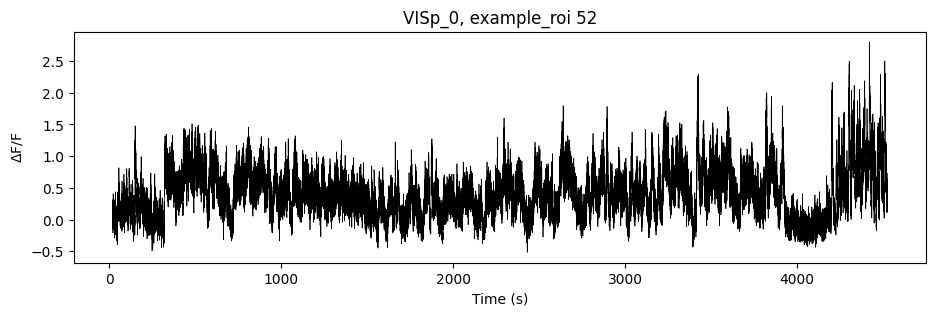

In [12]:
# Sanity check: plot one example_roi's trace against time.
# EDIT: try several -- cells differ enormously, and index 0 is not special.
# Here we take a high-SNR cell so the plot shows what real activity looks like.
# `dff` is already a QC-filtered numpy array from the cell above.

# Some cells can be entirely NaN (failed segmentation, dropped ROIs). Check
# before you index -- a NaN cell will silently poison anything it touches.
usable_cells = np.flatnonzero(~np.isnan(dff).all(axis=0))
print(f'{dff.shape[1]} cells, {len(usable_cells)} with any data')

snr = np.percentile(dff[:, usable_cells], 99, axis=0) / np.std(dff[:, usable_cells], axis=0)

# A cell can have a high ratio because it is reliably active, or because its
# baseline wanders. Those look nothing alike, and only one is a good example.
#
# Comparing the first quarter to the last quarter catches a steady climb, but it
# is blind to a cell that surges in the middle and returns -- the endpoints match.
# Compare block means across the whole session instead.
blocks = np.array_split(np.arange(len(ts)), 8)
block_means = np.array([dff[b][:, usable_cells].mean(axis=0) for b in blocks])
instability = block_means.std(axis=0) / (dff[:, usable_cells].std(axis=0) + 1e-9)

stable = np.flatnonzero(instability < 0.35)
if not len(stable):                          # nothing that stable -- relax and say so
    stable = np.flatnonzero(instability < 0.6)
    print('no cell with instability < 0.35; relaxing the threshold')
pick = stable[np.argmax(snr[stable])] if len(stable) else int(np.argmax(snr))
example_roi = int(usable_cells[pick])

print(f'plotting example_roi {example_roi} (SNR {snr[pick]:.2f}, instability '
      f'{instability[pick]:.2f}; {len(stable)}/{len(usable_cells)} cells pass)')

plt.figure(figsize=(11, 3))
plt.plot(ts, dff[:, example_roi], 'k', lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel(r'$\Delta$F/F')
plt.title(f'{plane}, example_roi {example_roi}')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Look at that trace for a few seconds before moving on. Is anything about it
surprising? Would you have noticed if you had skipped straight to the analysis?

</div>

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Two things are visible in our example cell, and only one of them is what you came for.

**The transients.** Sharp upward events on a flat baseline &mdash; this is what calcium activity
should look like, and it tells you the trace is a real signal rather than noise or an artifact.

**The slow envelope.** The activity is not stationary. In this cell the first quarter of the session
averages several times higher than the last quarter, with the largest transients in the middle. Other
cells in the same plane drift the *opposite* way, some by a factor of ten.

Slow changes like this can be biology (arousal, engagement, sensitization) or the recording (z-drift
changing which part of the cell is in focus). The trace alone cannot distinguish them, and this
notebook will not resolve it.

What matters is that you **saw it**, because it has consequences later: anything you compare between
the start and the end of the session is confounded with this trend, and any "response" measured
without subtracting a local baseline partly reflects where the cell's baseline happened to be.

Try a few different ROIs before moving on. Cells differ enormously, and picking index 0 tells you
about index 0. Write what you find in your README &mdash; one plot, thirty seconds, and you know
something no summary statistic would have told you.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Set up the main variables for this dataset</h3>

Point these names at the equivalent pieces of your own NWB file. Later sections reference them,
so getting them right here saves repeating yourself &mdash; but edit anything you like as you go.
This is your notebook now.

</div>

In [13]:
# =====================================================================
# FILL IN FOR YOUR DATASET
# =====================================================================
activity = dff                    # (n_timepoints, n_cells)
timestamps = ts                   # (n_timepoints,) seconds
events = stimulus_table           # one row per stimulus presentation


# A second activity representation, if your dataset has one (deconvolved
# events, spike estimates). Set to None if it does not -- the notebook adapts.
# NOTE: this must carry the same QC mask as `activity`.
activity_events = events_raw
second_signal_label = 'event magnitude'   # what activity_events holds; None if unused
# =====================================================================

print('activity:', activity.shape, '| events:', events.shape)
print('second representation:',
      'none' if activity_events is None else activity_events.shape)

activity: (42721, 77) | events: (4805, 13)
second representation: (42721, 77)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Print the columns of your stimulus table. Which describe *what was
presented*, which describe *what the animal did*, and which are bookkeeping?

Note any column whose meaning you cannot guess &mdash; that is a databook lookup for your README.

</div>

In [14]:
print(list(events.columns))
events.head()

['start_time', 'stop_time', 'image_name', 'orientation', 'is_change', 'omitted', 'stimulus_presentations_id', 'trials_id', 'start_frame', 'stop_frame', 'lick_latency', 'epoch_name', 'HED']


,start_time,stop_time,image_name,orientation,is_change,omitted,stimulus_presentations_id,trials_id,start_frame,stop_frame,lick_latency,epoch_name,HED
id,,,,,,,,,,,,,
0,318.873416,319.123626,im000,NaN,False,False,0,0,17985,18000,0.681244,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
1,319.624056,319.874256,im000,NaN,False,False,1,0,18030,18045,0.147454,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
2,320.374686,320.624896,im000,NaN,False,False,2,1,18075,18090,0.297594,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
3,321.125326,321.375536,im000,NaN,False,False,3,2,18120,18135,NaN,change_detection,"Sensory-event, Visual-presentation, (Image, La..."
4,321.875946,322.126166,im000,NaN,False,False,4,2,18165,18180,0.414364,change_detection,"Sensory-event, Visual-presentation, (Image, La..."


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In our example, `image_name` and `orientation` describe the stimulus; `is_change` and
`omitted` describe its role in the task; `lick_latency` is behavior; `trials_id` links to the trials
table; `HED` is a semantic annotation string.

`is_change` is the one that matters later. Most presentations repeat the previous image; a few are
changes the animal must report. Those are **not the same kind of event**, and treating them as
interchangeable would mix task-driven licking and reward into a stimulus analysis.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce the figure, and interrogate what it shows</h1>

You have your classmate's figure. You do not have their code, and you may not have a caption either.

<b>Before you write anything, write down what you think the figure shows.</b> One or two sentences,
in your notebook, as a claim someone could disagree with: <i>"activity is higher during X than during
Y"</i>, <i>"the response is larger on this trial type"</i>, <i>"these two signals rise together."</i>

Two reasons this comes first. It commits you to an interpretation before the data can talk you into
one &mdash; and it converts a picture into something you can actually test. A figure cannot be right
or wrong. A claim can.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write your claim about the figure you picked, in the cell below, before you
write any code.

Be specific enough to be wrong. "There is neural activity" is not a claim; "population activity is
higher in the second half of the session" is.

</div>

_Your claim:_

<!-- write it here -->


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

For the example figure &mdash; running speed and population activity across the session, with
epochs shaded &mdash; a reasonable claim is:

> *"Population activity is higher during the task block than during the gray-screen periods, and the
> mouse runs in bouts throughout."*

Note what makes this testable: it names two things to compare and asserts a direction. It is also
two claims, not one, and they may not both survive.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Now rebuild it</h3>

Get the pieces the figure needs and plot them. You will not match it exactly &mdash; different
smoothing, different colors, a different subset of cells &mdash; and that is fine. What matters is
that the structure you see is the same structure they saw.

If you cannot rebuild some element because the dataset does not contain it, note that and rebuild
what you can.

</div>

In [15]:
# The figure needs a population_rate average: mean across cells at each timepoint
population_rate = activity.mean(axis=1)

print('activity:  ', activity.shape, '(timepoints, cells)')
print('population:', population_rate.shape, '(timepoints,)')

activity:   (42721, 77) (timepoints, cells)
population: (42721,) (timepoints,)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To shade the epochs we need their start and stop times. Where epochs live varies by dataset:
sometimes an `epoch_name` column on the stimulus table, sometimes a separate epochs table.

**Check that the column you group by actually varies.** If it takes one value, you will get a single
block spanning the session &mdash; a figure that looks fine and is wrong.

</div>

In [16]:
# EDIT: does your stimulus table carry an epoch column, and does it vary?
# Do not guess column names -- they differ between datasets. Ask the table which
# of its columns are categorical (few distinct values), then look at those.
epoch_candidates = [column for column in events.columns
                    if column not in ('start_time', 'stop_time')
                    and events[column].nunique() <= 12]
print(f'{len(epoch_candidates)} column(s) with 12 or fewer distinct values\n')
for column in epoch_candidates:
    print(f'{column}: {events[column].nunique()} distinct value(s)')
    print(events[column].value_counts().to_string())
    print()

5 column(s) with 12 or fewer distinct values

image_name: 9 distinct value(s)
image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161

orientation: 0 distinct value(s)
Series([], )

is_change: 2 distinct value(s)
is_change
False    4614
True      191

omitted: 2 distinct value(s)
omitted
False    4644
True      161

epoch_name: 1 distinct value(s)
epoch_name
change_detection    4805



<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In our example the stimulus table carries an epoch column that takes exactly **one**
value, so grouping by it would produce a single block spanning the session &mdash; a figure that
looks fine and is wrong. The real boundaries live in a separate intervals table.

Other datasets go the other way: the stimulus table's epoch column varies properly and is all you
need. Either is fine; the check is what matters. **A column existing does not mean it carries the
information you want.**

</div>

In [17]:
# EDIT: where the epochs live in your dataset
intervals_table = nwb.intervals['intervals'].to_dataframe()

# This table mixes several kinds of interval; keep only the epochs.
epochs = intervals_table[intervals_table.interval_type == 'epoch']
epochs = epochs.set_index('label')[['start_time', 'stop_time']].sort_values('start_time')
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs

,start_time,stop_time,duration_s
label,,,
spontaneous,0.000000,318.837390,318.8
change_detection,318.837390,3925.469850,3606.6
spontaneous,3925.469850,4225.759726,300.3
natural_movie_one,4225.759726,4526.013479,300.3


In [18]:
# Shade each epoch a different color -- same helper as the tutorial
colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))


def shade_epoch_blocks(ax):
    """Shade each epoch on `ax`, one colour per epoch label.

    Epochs are the coarse structure of the session -- which stimulus block or
    task phase was running. Shading them behind a trace shows at a glance
    whether a change in activity lines up with a change in what was happening.
    """
    for label, row in epochs.iterrows():
        # zorder=0 keeps the shading BEHIND the data; alpha so the trace on top
        # stays readable. label= puts each epoch in the legend once.
        ax.axvspan(row.start_time, row.stop_time, color=colors[label],
                   alpha=0.5, zorder=0, label=label)


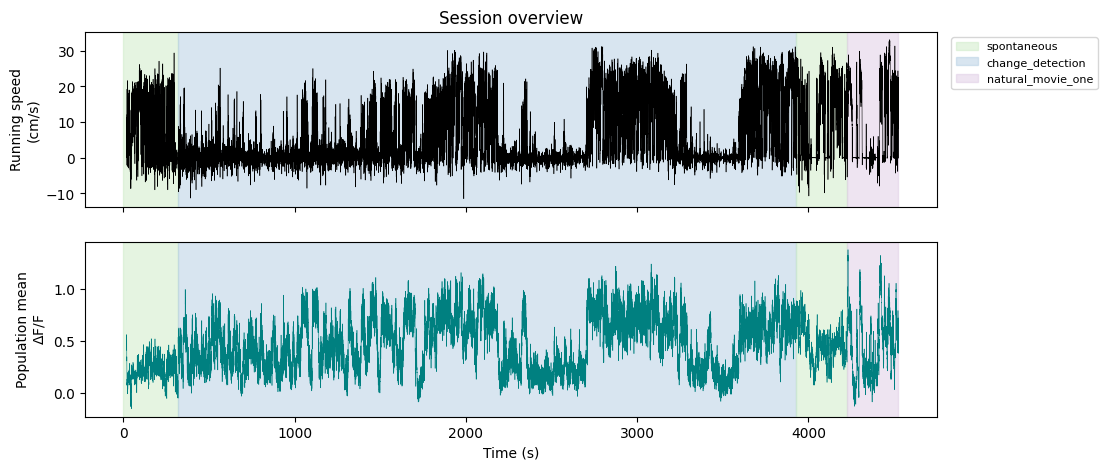

In [19]:
# Build the panels from whatever behavior streams this dataset actually has.
# EDIT: add or remove entries to match your dataset.
panels = [(timestamps, population_rate, 'Population mean\n' + r'$\Delta$F/F', 'teal')]

if 'running_speed' in dir():
    panels.insert(0, (running_ts, running_speed, 'Running speed\n(cm/s)', 'k'))

fig, axes = plt.subplots(len(panels), 1, figsize=(11, 2.5 * len(panels)),
                         sharex=True, squeeze=False)
axes = axes[:, 0]

for ax, (x, y, ylabel, color) in zip(axes, panels):
    ax.plot(x, y, color=color, lw=0.4)
    ax.set_ylabel(ylabel)
    shade_epoch_blocks(ax)

axes[0].set_title('Session overview')
axes[-1].set_xlabel('Time (s)')

handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
axes[0].legend(unique.values(), unique.keys(), bbox_to_anchor=(1.01, 1.0),
               loc='upper left', fontsize=8)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now test the claim you wrote above &mdash; do not eyeball it.

Turn your sentence into a number you can check. If it compares epochs, compute the mean in each one,
alongside how long each epoch lasted, when in the session it happened, and what the animal was doing.
If it compares something else, compute the equivalent.

Before you look: **what would make this comparison unfair?** Write your answer down first, then see
whether the table bears it out.

Then go back and mark your claim as supported, contradicted, or untestable with this data. All three
are legitimate outcomes and all three belong in your README.

</div>

In [20]:
# Add the two things that could confound the comparison: when the epoch
# happened, and what the animal was doing during it.
response_rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    in_epoch_run = (running_ts >= row.start_time) & (running_ts < row.stop_time)
    if in_epoch.sum() < 10:
        continue
    response_rows.append({'epoch': label,
                 'duration_s': round(float(row.stop_time - row.start_time), 1),
                 'n_samples': int(in_epoch.sum()),
                 'mid_session_min': round(float(row.start_time + row.stop_time) / 120, 1),
                 'mean_running': round(float(running_speed[in_epoch_run].mean()), 2),
                 'mean_activity': round(float(population_rate[in_epoch].mean()), 4)})

pd.DataFrame(response_rows)

,epoch,duration_s,n_samples,mid_session_min,mean_running,mean_activity
0,spontaneous,318.8,2844,2.7,8.11,0.2140
1,change_detection,3606.6,34186,35.4,6.02,0.4841
2,spontaneous,300.3,2846,67.9,10.06,0.4786
3,natural_movie_one,300.3,2845,72.9,8.91,0.4566


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Read `duration_s` and `n_samples` before you read `mean_activity`.

**Unshaded stretches are not nothing.** If your epoch table leaves gaps, those intervals simply had
no epoch defined &mdash; often a break between acquisition blocks. Neural recording may continue
through them while behavioral streams stop, so the same interval can be present in one signal and
missing from another. Do not assume an unshaded region is comparable to a shaded one.

Our example session has no such gaps: both traces are continuous end to end and the epoch table
covers the session. That is the ordinary case.

It does have a duration problem. Three of its four epochs are 300-320 s, but the task block is
3605 s &mdash; eleven times longer. A mean over 300 s and a mean over 3600 s are not equally precise
estimates, so ranking them tells you less than the table's tidy appearance suggests.

**The deeper problem is that epochs are ordered in time.** Look at `mid_session_min`: the epochs march
through the session, so any slow change &mdash; indicator bleaching, the animal warming up or tiring,
arousal drifting &mdash; is perfectly aligned with epoch identity. In some sessions `mean_activity`
climbs monotonically with epoch order, which makes the confound obvious. In others the first
spontaneous block is simply far below the rest and the remaining three are flat, which looks like a
real epoch effect and is equally unsafe. Either way you cannot tell the two apart from this table.

`mean_running` is in the table for the same reason: it differs across epochs too, so a difference in
activity may be a difference in movement. **A difference between epochs is not evidence about what the
epochs contain unless you can separate it from when they happened and what the animal was doing.**

If you want the comparison, one option is to sample equal-length windows from each epoch, matched for
running speed, and interleave them &mdash; the notebook does not do this, and saying so is part of the
answer.

**Check the direction of the claim first.** For the example claim written above it does not hold:
activity during the change-detection block is *lower* than during the gray-screen periods, the
opposite of what the claim asserts. Run this on a different session from the same mouse and the
direction can flip again. The figure itself does not settle it &mdash; the traces are too dense to
read a mean off by eye.

That is the point, and it is why you wrote the claim down before computing anything. The figure is
not wrong. The sentence you attached to it was a guess, and a plausible sentence beside a real figure
is easy to believe.

Even once you have the direction right, the comparison is confounded, and the extra columns show how.
Read them down the table together:

- `mean_activity` &mdash; the quantity the claim is about.
- `mid_session_min` &mdash; epochs run in a fixed order, so epoch is perfectly confounded with time.
- `mean_running` &mdash; and with what the animal was doing.

If activity and one of those other columns move together across epochs, you cannot tell which one is
responsible. Indicators bleach and animals disengage over an hour, and running drives visual cortex
strongly on its own. Whether these line up helpfully or not is luck, and it differs between sessions.

Note the durations too: the task block runs an order of magnitude longer than the others, so the means
are not equally precise estimates.

No statistical test fixes any of this &mdash; these are properties of the experimental design, which
is why you check them before running the analysis. The honest comparison uses equal-duration windows
matched for time in session and running state. Write in your README what you would need to test the
claim properly, and if the session cannot support it, say so.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Align activity to event onsets</h1>

The session overview shows everything at once, which means it shows very little. To see a response
you need to **align** activity to the times when something happened, and look across repeats.

"Something happened" need not be a visual stimulus. It might be a sound, an optogenetic pulse, a
reward, a lick, or the start of a trial. Anything with a repeatable onset time works the same way
&mdash; and the rest of this notebook says "event" rather than "stimulus" for that reason.

This morning's tutorial averaged across presentations. Here we look at what the average hides.

</div>

In [21]:
# Which column labels the chosen_condition? Look at the candidates first.
for col in ['image_name', 'is_change', 'omitted', 'stimulus_block_name']:
    if col in events.columns:
        print(f'--- {col} ---')
        print(events[col].value_counts().head(10).to_string())
        print()
condition_column = 'image_name'
# How many times was each chosen_condition presented?
events[condition_column].value_counts()

--- image_name ---
image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161

--- is_change ---
is_change
False    4614
True      191

--- omitted ---
omitted
False    4644
True      161



image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161
Name: count, dtype: int64

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Are all of these events the same kind of event?</h3>

An event table usually contains rows that are **not equivalent trials**. Depending on the dataset
that might be first versus repeated presentations, rewarded versus unrewarded trials, different
stimulus families, trials the animal responded to versus ignored, blocks recorded before and after
a manipulation, or blank and omitted entries that are not events at all.

This matters before you align anything, for two reasons:

- **Response magnitude can differ several-fold between trial types.** Averaging them together dilutes
  the response toward whichever type is most numerous &mdash; which is often the weakest one.
- **Trial types differ in what else is happening.** Reward, licking, and arousal ride along with some
  trial types and not others, so a difference you attribute to the stimulus may not be about the
  stimulus.

Find the columns in your table that distinguish trial types, and count them.

</div>

In [22]:
# EDIT: which columns in your table distinguish kinds of trials?
# Same rule as before: let the table tell you which columns distinguish trials,
# rather than assuming names from another dataset.
trial_type_columns = [column for column in events.columns
                      if column not in ('start_time', 'stop_time')
                      and 1 < events[column].nunique() <= 12]
print(f'{len(trial_type_columns)} column(s) that split trials into groups\n')
for column in trial_type_columns:
    print(f'{column}:')
    print(events[column].value_counts().to_string())
    print()

3 column(s) that split trials into groups

image_name:
image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161

is_change:
is_change
False    4614
True      191

omitted:
omitted
False    4644
True      161



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To compare them we need to cut a window of data around each onset. Same
`align_to_event_times` helper as this morning's tutorial.

</div>

In [23]:
def align_to_event_times(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    data        : array with time along the first axis
    timestamps  : time of each row of data, in seconds
    event_times : times to align to, in seconds
    pre, post   : seconds before and after each event

    Returns (aligned_windows, window_time_axis) where the time axis is in
    seconds relative to the event, and there is one window per usable_cells event.
    """
    # Sampling interval. Median, not mean: one gap in the recording would
    # inflate a mean and silently shrink every window.
    dt = np.median(np.diff(timestamps))

    # Convert the requested seconds into a number of samples. int() truncates,
    # so a window that is not a whole number of samples comes out slightly
    # short -- check this if you need exact window edges.
    n_pre, n_post = int(pre / dt), int(post / dt)

    aligned_windows = []
    for event_time in event_times:
        # Index of the first sample AT OR AFTER the event. side='left' returns
        # the insertion point, so timestamps[i] >= event_time always.
        #
        # Do NOT round to the nearest sample: that pulls roughly half the
        # trials one sample EARLIER than the event, which smears the onset and
        # can make a real response look like it starts before the stimulus.
        # Landing just after is honest -- the bias is one-directional and at
        # most one sample.
        i = np.searchsorted(timestamps, event_time, side='left')

        # Skip events too close to either end of the recording to fill a whole
        # window. This drops trials SILENTLY, so compare
        # aligned_windows.shape[0] against len(event_times) afterwards.
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            # Slice is n_pre + n_post samples long. Index n_pre within the
            # window is the first sample at/after the event, i.e. t = 0.
            aligned_windows.append(data[i - n_pre:i + n_post])

    # Time axis in seconds relative to the event. Starts at -n_pre*dt, which
    # can be slightly later than -pre because of the truncation above.
    window_time_axis = np.arange(-n_pre, n_post) * dt
    return np.array(aligned_windows), window_time_axis


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pick two trial types from your table and align the population average to
each separately, then plot both on the same axes.

Write down your prediction first: do you expect a difference, and how large?

Then choose which type to carry forward, and one condition within it. Name the things below, because
the rest of Part 3 refers to them:

| name | what it holds |
| --- | --- |
| `stimulus_onset_times` | onset times of ALL trials of your chosen type |
| `onset_times` | onset times of the one condition you picked |

</div>

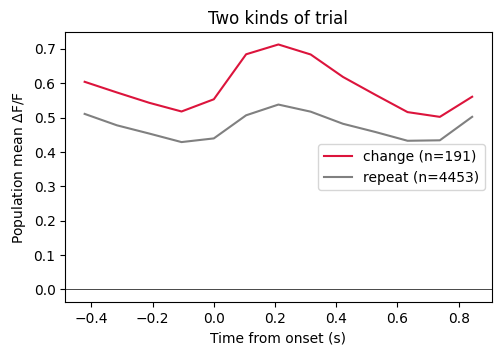

In [24]:
onset_column = 'start_time'
population_rate = activity.mean(axis=1)

# EDIT: define two groups of onset_times to compare in your dataset.
# Here: image changes vs. repeated presentations of the same images.
change_onset_times = events.loc[events.is_change == 1, onset_column].values
repeat_onset_times = events.loc[(events.is_change != 1) & (events.omitted != 1), onset_column].values

plt.figure(figsize=(5.5, 3.5))
# Only plot a group with enough trials to average -- a single-trial "average"
# is just that trial, and it will look like a result.
min_trials = 10
groups = [(change_onset_times, 'change', 'crimson'), (repeat_onset_times, 'repeat', 'gray')]
for onset_times_this_group, label, color in [g for g in groups if len(g[0]) >= min_trials]:
    aligned_windows_group, window_time_axis = align_to_event_times(population_rate, timestamps, onset_times_this_group,
                                           pre=0.5, post=1.0)
    mean_response = aligned_windows_group.mean(axis=0)
    plt.plot(window_time_axis, mean_response, color=color,
             label=f'{label} (n={len(aligned_windows_group)})')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Time from onset (s)')
plt.ylabel("Population mean " + r"$\Delta$F/F")
plt.legend()
for onset_times_this_group, label, _ in groups:
    if len(onset_times_this_group) < min_trials:
        print(f'skipped {label}: only {len(onset_times_this_group)} trial(s) -- too few to average')

plt.title('Two kinds of trial')
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In our example the two trial types differ by roughly **four-fold**: one evokes a clear
population response peaking about 0.2&nbsp;s after onset, the other barely rises above baseline. Both
show the same images for the same duration.

The size of that gap is the useful number. It tells you that pooling these trials would have diluted
the response by most of its magnitude, and it sets your expectation for everything downstream: an
analysis run on the weaker type needs many more trials to see the same effect.

It also tells you which comparison you can actually interpret. If the two types differ in reward,
licking, or arousal as well as in stimulus history, then a difference between them is not
attributable to the stimulus alone.

**Whenever a trial-aligned average comes out flat, check this before anything else.** Align to the
trial type that should be most strongly driven and confirm you can see a response there. A flat
average from a poorly chosen trial type looks identical to a flat average from a timing error, and
this check distinguishes them in one plot.

</div>

In [25]:
# Which column labels the chosen_condition? Look at the candidates first.
for col in ['image_name', 'is_change', 'omitted', 'stimulus_block_name']:
    if col in events.columns:
        print(f'--- {col} ---')
        print(events[col].value_counts().head(10).to_string())
        print()
condition_column = 'image_name'
onset_column = 'start_time'
# EDIT: work with the more strongly driven trial type from here on
stimulus_onset_times = change_onset_times
is_selected_trial_type = events.is_change == 1        # EDIT: matches change_onset_times above

chosen_condition = events.loc[is_selected_trial_type, condition_column].value_counts().index[0]
onset_times = events.loc[is_selected_trial_type & (events[condition_column] == chosen_condition),
                    onset_column].values

print(f'condition: {chosen_condition} | presentations of this type: {len(onset_times)}')

--- image_name ---
image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161

--- is_change ---
is_change
False    4614
True      191

--- omitted ---
omitted
False    4644
True      161

condition: im075 | presentations of this type: 25


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Which cell or unit to look at?</h3>

Whatever your dataset calls them &mdash; ROIs in an imaging plane, sorted units on a probe &mdash;
taking the first one in the table is an arbitrary choice you did not disclose. Ranking by how strongly
they respond is a *different* undisclosed choice unless you say so. Pick deliberately and write down
how you picked.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Which signal do you align?</b> Most datasets ship more than one representation of the
same activity, and the choice is yours &mdash; but it is a choice, and it changes what the figures
show.

<table>
<tr><td><b>&Delta;F/F</b> (imaging)</td><td>Continuous fluorescence. Carries the indicator's rise and
decay, so a brief response is smeared forward by hundreds of milliseconds, and slow drift shared
across the field of view inflates correlations between any two cells. Every timepoint has a
value.</td></tr>
<tr><td><b>Deconvolved events</b> (imaging)</td><td>An estimate of when the cell actually fired, with
the indicator kinetics removed. Temporally tighter, and mostly exact zeros &mdash; so single-trial
estimates are much noisier even though the trial average looks cleaner.</td></tr>
<tr><td><b>Spike times</b> (electrophysiology)</td><td>Discrete times, no continuous trace at all. You
choose a bin width to get a matrix, and that width is a real analysis decision: too fine and every
bin is empty, too coarse and you lose the timing you came for.</td></tr>
</table>

None of these is the correct one. A question about response <i>latency</i> or duration is badly served
by &Delta;F/F; a question needing a reliable per-trial number is badly served by a sparse signal. Pick
one, say why, and if you have time run the analysis twice and compare &mdash; that comparison is
usually more informative than either result alone.

<b>Set the choice in one place</b> so switching it is a one-line edit rather than a rewrite.

</div>

In [26]:
# EDIT: which signal to align, and what to call it on the axes.
# Whatever you choose must be (n_timepoints, n_cells) on `timestamps`.
#   imaging   -> the continuous trace, or the deconvolved events
#   ephys     -> your binned spike counts or rates
aligned_signal = activity
signal_label = 'dF/F'

print('aligning', signal_label, '|', aligned_signal.shape)

aligning dF/F | (42721, 77)


In [27]:
pre, post = 0.5, 1.0

# Rank cells on ALL trials of this type, not just one chosen_condition.
# NOTE: this re-selects example_roi against the CURRENT `activity` matrix. If you
# comparable_trials or reorder cells at any point, indices from earlier cells no longer
# refer to the same neurons -- always re-derive them rather than carrying
# an index across a reshape.
after = np.array([aligned_signal[(timestamps >= t0) & (timestamps < t0 + 0.5)].mean(axis=0)
                  for t0 in stimulus_onset_times])
before = np.array([aligned_signal[(timestamps >= t0 - 0.25) & (timestamps < t0)].mean(axis=0)
                   for t0 in stimulus_onset_times])

# Use nanmean/nanstd: a single trial with an incomplete window (one that runs
# off the start or end of the recording) would otherwise turn EVERY cell's
# score into NaN, and you would conclude no cell responds.
difference = after - before
with np.errstate(invalid='ignore'):
    modulation = np.nanmean(difference, axis=0) / np.nanstd(difference, axis=0)

n_dropped = int(np.isnan(modulation).sum())
if n_dropped:
    print(f'{n_dropped} cells have no usable data and were skipped')
example_roi = int(np.nanargmax(modulation))

print(f'most stimulus-modulated cell: example_roi {example_roi} (score {modulation[example_roi]:.3f})')
print(f'median across cells: {np.nanmedian(modulation):.3f}')

most stimulus-modulated cell: example_roi 12 (score 2.016)
median across cells: 0.732


In [28]:
aligned_windows, t = align_to_event_times(aligned_signal[:, example_roi], timestamps, onset_times, pre=pre, post=post)

print('windows shape (n_presentations, n_frames):', aligned_windows.shape)

windows shape (n_presentations, n_frames): (25, 13)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compare the number of windows you got back against the number of onsets you
asked for. Are they the same?

If not, read the helper again and work out where the missing trials went &mdash; then decide whether
losing them matters for your analysis.

This is worth doing every time you call something that returns one row per trial. A function that
quietly returns fewer rows than you gave it will not raise an error; it will just make your
n smaller than you think it is.

</div>

In [29]:
print('onsets:           ', len(onset_times))
print('windows returned: ', aligned_windows.shape[0])
print('trials dropped:   ', len(onset_times) - aligned_windows.shape[0])

onsets:            25
windows returned:  25
trials dropped:    0


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

`align_to_event_times` skips any event whose window would run off the start or end of the
recording &mdash; sensible, since those windows would be the wrong length. But it does it
**silently**.

If you never compare the two numbers, every trial count you report downstream is quietly wrong. This
is a small instance of a large category: helper functions make reasonable decisions for you, and
those become invisible assumptions. **Check the shape of what comes back against what you expected.**

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Raster and PSTH</h3>

The raster shows every trial; the PSTH is their average. Plot them together so you can see what the
average discards.

</div>

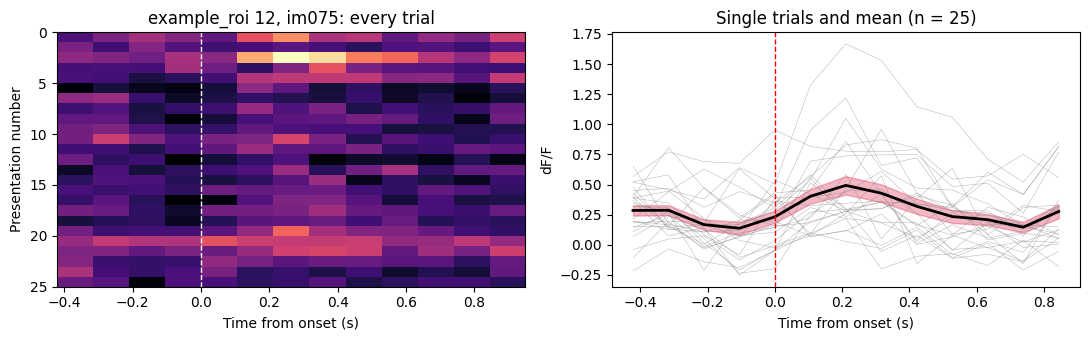

In [30]:
mean = aligned_windows.mean(axis=0)
standard_error = aligned_windows.std(axis=0) / np.sqrt(len(aligned_windows))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

sample_width = float(np.median(np.diff(t)))
axes[0].imshow(aligned_windows, aspect='auto', cmap='magma', interpolation='nearest',
               extent=[t[0], t[-1] + sample_width, aligned_windows.shape[0], 0])
axes[0].axvline(0, color='white', ls='--', lw=1)
axes[0].set_xlabel('Time from onset (s)')
axes[0].set_ylabel('Presentation number')
axes[0].set_title(f'example_roi {example_roi}, {chosen_condition}: every trial')

axes[1].plot(t, aligned_windows.T, color='gray', lw=0.3, alpha=0.7)
axes[1].plot(t, mean, 'k', lw=2)
axes[1].fill_between(t, mean - standard_error, mean + standard_error, color='crimson',
                     alpha=0.3)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_xlabel('Time from onset (s)')
axes[1].set_ylabel(signal_label)
axes[1].set_title(f'Single trials and mean (n = {len(aligned_windows)})')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Almost no individual trial looks like the average. The mean shows a modest post-onset bump;
the single trials behind it are mostly empty, with activity on a minority and a few large events
scattered before onset as well as after.

On a sparse signal this is unmistakable: the raster is visibly mostly black. On a continuous trace the
same fact is there but harder to see, because the indicator's decay fills the gaps between events and
every row looks like it contains something. **The averaged figure looks the same either way.**

This is normal cortical data, not a quality problem. But it sets up the rest of the notebook: **the
average is a small signal pulled out of large variability**, and how much you can trust it depends
entirely on how many trials went into it.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now do it for every cell and plot the result as a heatmap, sorted by
response magnitude. How many cells respond at all?

</div>

In [31]:
responses = []
for roi in range(aligned_signal.shape[1]):
    windows_roi, t = align_to_event_times(aligned_signal[:, roi], timestamps, onset_times, pre=pre, post=post)
    responses.append(windows_roi.mean(axis=0))

responses = np.array(responses)
print('responses shape (n_cells, n_timepoints):', responses.shape)

responses shape (n_cells, n_timepoints): (77, 13)


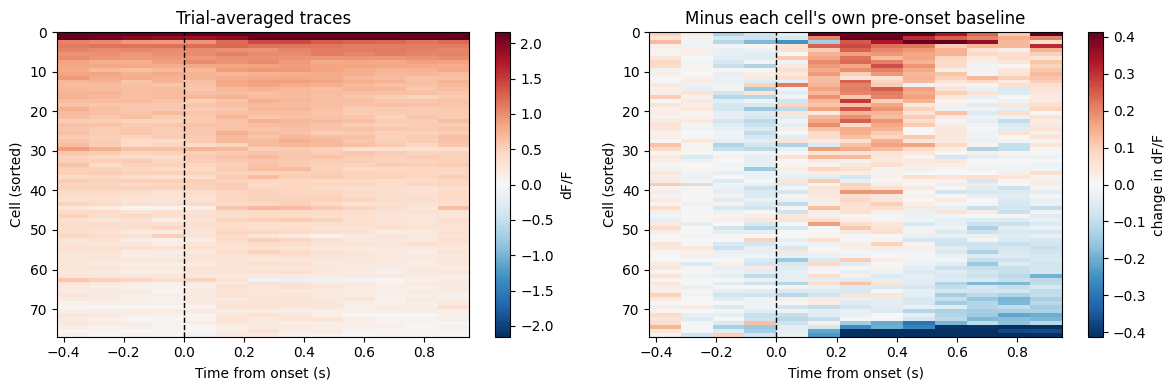

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LEFT: raw trial-averaged traces, sorted by their mean
order_raw = np.argsort(responses.mean(axis=1))[::-1]
color_limit = np.nanpercentile(np.abs(responses), 98)
sample_width = float(np.median(np.diff(t)))
im0 = axes[0].imshow(responses[order_raw], aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-color_limit, vmax=color_limit,
                     extent=[t[0], t[-1] + sample_width, len(responses), 0])
axes[0].set_title('Trial-averaged traces')
plt.colorbar(im0, ax=axes[0], label=signal_label)

# RIGHT: same thing, minus each cell's own pre-onset baseline
# Exclude the sample adjacent to onset: with binned data it can straddle
# the event, putting response into the baseline.
bin_width = np.median(np.diff(t))
baseline = responses[:, t < -bin_width].mean(axis=1, keepdims=True)
change = responses - baseline

order = np.argsort(change[:, t >= 0].mean(axis=1))[::-1]
color_limit = np.nanpercentile(np.abs(change), 98)
im1 = axes[1].imshow(change[order], aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-color_limit, vmax=color_limit,
                     extent=[t[0], t[-1] + sample_width, len(change), 0])
axes[1].set_title("Minus each cell's own pre-onset baseline")
plt.colorbar(im1, ax=axes[1], label='change in ' + signal_label)

for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel('Cell (sorted)')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

These two panels are the same data and tell different stories &mdash; that is the lesson.

The left panel looks like a clean ranking of responsive cells, but it is mostly showing **which cells
are more active overall**, not which cells respond to the stimulus. Each row is nearly flat in time; the vertical
gradient is baseline, not stimulus. Sorting by the row mean sorts by baseline.

The right panel subtracts each cell's own pre-onset baseline, so what is left is the *change* the
stimulus produced. Now a minority of cells respond, most barely at all, and a few are suppressed
&mdash; and the structure runs left-to-right (before vs after onset) rather than top-to-bottom.

One transformation, entirely different interpretation. Neither panel is wrong; the first just does not
answer the question we asked of it. **This is why you plot after each step.**

Two kinds of variability are now on the table, and the distinction drives Part 4:

- **Across trials** (the raster): one neuron, one stimulus, a different response each time.
- **Across neurons** (the right panel): different neurons doing genuinely different things.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The same analysis on a different signal</h3>

<b>Skip this section if your dataset has only one representation of activity.</b> A probe recording
gives you spike times and nothing else &mdash; there is no second signal to compare against, and
saying so in your write-up is the correct answer here, not a gap.

If you do have two &mdash; a continuous trace and a deconvolved estimate, most commonly &mdash; they
are not interchangeable, and running the same analysis on both is the cheapest way to find out how
much your conclusion depends on that choice.

<b>Check what your dataset has before assuming.</b> List the interfaces in the processing container
and see whether a second per-cell timeseries is there at all.

</div>

In [33]:
# activity_events came from the fill-in cell. Clean tiny float noise to exact zeros
# so "fraction exactly zero" means what it says.
activity_events = np.where(np.abs(activity_events) < 1e-12, 0.0, activity_events)

print('dff:    ', activity.shape, '| fraction exactly zero: %.3f' % (activity == 0).mean())
print('events: ', activity_events.shape,
      '| fraction exactly zero: %.3f' % (activity_events == 0).mean())
print('timestamps shared:', activity_events.shape[0] == len(timestamps))

dff:     (42721, 77) | fraction exactly zero: 0.000
events:  (42721, 77) | fraction exactly zero: 0.853
timestamps shared: True


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** If your dataset has two activity representations, align both to the same
onsets and plot the trial-averaged population response side by side. What differs &mdash; the
duration, the shape, the size relative to baseline?

If it has only one, note that in your README and move on.

</div>

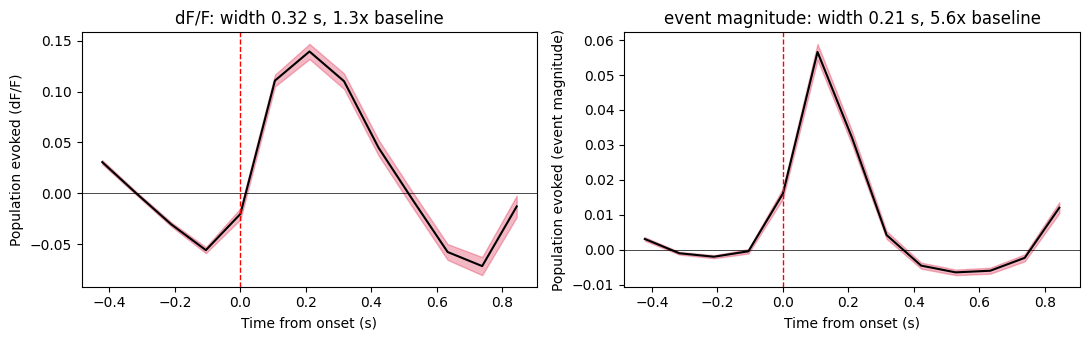

In [34]:
# Two representations to compare, or one? Build the list first.
comparison = [(signal_label, activity)]
if activity_events is not None:
    comparison.append((second_signal_label, activity_events))

if len(comparison) == 1:
    print('Only one activity representation in this dataset -- nothing to compare here.')
    print('Say so in your write-up and continue to Part 4.')

fig, axes = plt.subplots(1, len(comparison), figsize=(5.5 * len(comparison), 3.5),
                         squeeze=False)

for ax, (label, A) in zip(axes[0], comparison):
    windows_pop, t_pop = align_to_event_times(A.mean(axis=1), timestamps, stimulus_onset_times,
                                         pre=0.5, post=1.0)
    # Exclude the sample adjacent to onset: with binned data that sample can
    # straddle the event, which would put response into the baseline.
    bin_width = np.median(np.diff(t_pop))
    baseline = windows_pop[:, t_pop < -bin_width].mean(axis=1, keepdims=True)
    evoked_response = (windows_pop - baseline)

    mean = evoked_response.mean(axis=0)
    standard_error = evoked_response.std(axis=0) / np.sqrt(len(evoked_response))

    # width at half maximum, and how far above baseline the peak sits
    above_half = mean > mean.max() / 2
    width = above_half.sum() * np.median(np.diff(t_pop))
    raw = windows_pop.mean(axis=0)
    contrast = raw.max() / raw[t_pop < 0].mean()

    ax.plot(t_pop, mean, 'k')
    ax.fill_between(t_pop, mean - standard_error, mean + standard_error, color='crimson',
                    alpha=0.3)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel(f'Population evoked ({label})')
    ax.set_title(f'{label}: width {width:.2f} s, {contrast:.1f}x baseline')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Three differences worth naming.

**Duration.** The events response is narrower &mdash; in our session roughly a single frame at half
maximum against three or four for dF/F, and its mass sits earlier. dF/F inherits the indicator's rise
and decay, which smears activity forward in time; deconvolution is an attempt to undo that. If you
care about response duration, or about ordering responses across areas or cells, this is not a
detail.

**Contrast.** Relative to its own pre-onset baseline the events signal rises proportionally more
(roughly 2&times; versus 1.4&times; here), because deconvolution removes the slowly varying
fluorescence dF/F carries between transients.

**Sparsity.** The events trace is around 90% exact zeros. That is the point of it &mdash; but it means
single-trial, single-cell estimates are mostly zero, so anything computed per trial is far noisier
even though the population average looks cleaner. We will see that cost in Part 4.

<b>A caution about reading latency off either panel.</b> At roughly 10&nbsp;Hz one frame is about
100&nbsp;ms, so "peaks one frame earlier" is at the limit of what this sampling rate can resolve, and
which frame wins can change between sessions. Whenever you quote a latency, check it against your
frame interval first &mdash; a difference smaller than one sample is not a measurement. Duration and
contrast, measured across several frames, are the more robust comparisons here.

Neither signal is more correct. dF/F is a smoothed, always-present measure; events are a sparse
estimate of a latent variable and inherit whatever assumptions the deconvolution made. **Report which
one you used**, because a reader cannot tell from the figure and your numbers depend on it.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: Signal and noise correlations</h1>

<h3>First, the math</h3>

The Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words:

1. **Center** each variable by subtracting its mean.
2. **Multiply** the centered values pointwise and sum &mdash; large and positive when they vary
   together, negative when oppositely, near zero when unrelated.
3. **Normalize** by each variable's spread, forcing the result between -1 and +1.

Compute it once by hand before running it thousands of times.

</div>

In [35]:
# two cells' full traces
x = activity[:, example_roi]
y = activity[:, example_roi + 1]

# Step 1: center
x_centered = x - x.mean()
y_centered = y - y.mean()

# Step 2: multiply and sum
numerator = np.sum(x_centered * y_centered)

# Step 3: normalize by the spread of each
denominator = np.sqrt(np.sum(x_centered ** 2)) * np.sqrt(np.sum(y_centered ** 2))

print('n observations:  ', len(x))
print('r by hand:       ', round(numerator / denominator, 6))
print('r from np.corrcoef:', round(np.corrcoef(x, y)[0, 1], 6))

n observations:   42721
r by hand:        0.143266
r from np.corrcoef: 0.143266


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Two consequences that matter for everything below:

- $r$ says nothing about response **size**, only whether two things move together.
- $r$ is computed over a set of paired observations, and **how many observations you have determines
  how noisy $r$ is** &mdash; but the value itself gives you no clue how many there were.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What does a given value of $r$ look like? Simulate pairs with known
correlations and plot them.

</div>

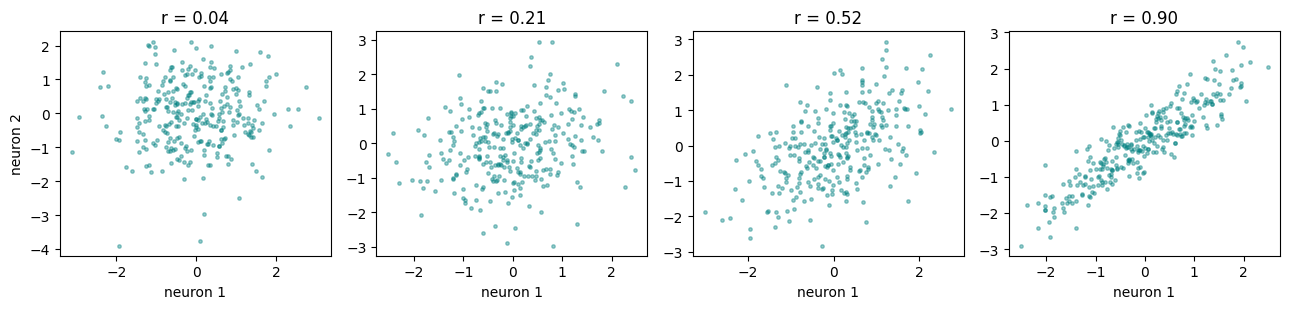

In [36]:
rng = np.random.default_rng(0)
n = 300

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))

for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    a = rng.normal(size=n)
    b = target_r * a + np.sqrt(1 - target_r ** 2) * rng.normal(size=n)
    ax.scatter(a, b, s=6, alpha=0.4, color='teal')
    ax.set_title(f'r = {np.corrcoef(a, b)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')

axes[0].set_ylabel('neuron 2')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

An $r$ of 0.2 looks like a formless blob; 0.5 is a cloud you would not confidently call a
relationship by eye.

Remember these pictures. Mean pairwise correlations in cortex are typically 0.01&ndash;0.1 &mdash;
weaker than the leftmost panel. Real and consequential at the population level, but no single pair
looks impressive.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Two reasons neurons are correlated</h3>

- **Signal correlation.** Do they respond similarly *across conditions*? Correlate the two neurons'
  tuning curves &mdash; their average response to each condition.
- **Noise correlation.** When the *same* condition repeats, do they fluctuate together around their
  own averages? Subtract each condition's mean and correlate the residuals.

A "condition" is whatever your event table repeats: an image, a grating direction, a tone, a
photostimulation target, a task context. All that matters is that it recurs enough times to average
over.

Same data, different thing averaged over:

| | what is correlated | one observation is |
| --- | --- | --- |
| signal | condition means | one condition |
| noise | within-condition residuals | one trial |

That last column matters more than anything else in this notebook.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: choose which events to use</h3>

Not every event is comparable to every other. Decide which subset is a fair comparison and write down
why.

</div>

In [37]:
# Which column labels the chosen_condition? Look at the candidates first.
for col in ['image_name', 'is_change', 'omitted', 'stimulus_block_name']:
    if col in events.columns:
        print(f'--- {col} ---')
        print(events[col].value_counts().head(10).to_string())
        print()
condition_column = 'image_name'
onset_column = 'start_time'
# EDIT: restrict to comparable events for your dataset.
#
# Decide which rows of your event table are equivalent trials, and drop the rest.
# Write down WHY -- this choice belongs in your methods.
comparable_trials = events.copy()

# Drop entries that are not stimuli at all.
if 'omitted' in comparable_trials.columns:
    comparable_trials = comparable_trials[comparable_trials['omitted'] != 1]

# If one trial type dominates, keeping only the other leaves you with nothing.
# Check the counts before you filter on a column, not after.
if 'is_change' in comparable_trials.columns:
    counts = comparable_trials['is_change'].value_counts()
    print('is_change counts:', counts.to_dict())
    if counts.get(False, 0) >= 20:
        comparable_trials = comparable_trials[comparable_trials['is_change'] != 1]
        print('-> keeping repeats only')
    else:
        print('-> too few repeats to separate; keeping all presentations')

all_onset_times = comparable_trials[onset_column].values
labels = comparable_trials[condition_column].values

print(f'\n{len(events)} events -> {len(comparable_trials)} after filtering')
print(pd.Series(labels).value_counts().to_string())

--- image_name ---
image_name
im106      771
im031      699
im075      597
im045      582
im000      548
im054      537
im073      480
im035      430
omitted    161

--- is_change ---
is_change
False    4614
True      191

--- omitted ---
omitted
False    4644
True      161

is_change counts: {False: 4453, True: 191}
-> keeping repeats only

4805 events -> 4453 after filtering
im106    746
im031    676
im075    572
im045    557
im000    523
im054    514
im073    457
im035    408


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Part 3 aligned to one strongly driven trial type; here we ask which rows belong in the
correlation analysis at all, and the answer depends on what your table contains.

**Check the counts before you filter on a column.** Our example session has ~4400 repeats against
~220 changes, so keeping the repeats is safe and we do. Other sessions of the same task are almost
entirely changes &mdash; there, the same filter would leave a handful of trials and every downstream
number would be undefined. The cell above prints the counts and adapts, rather than assuming.

Given both in quantity, the trade-off is real and worth stating:

| | changes only | repeats only |
| --- | --- | --- |
| trials | fewer | many more |
| stimulus drive | strong | weaker (adapted) |
| confounds | reward, licking, arousal ride along | behaviorally quieter |

For **noise** correlations the trial count usually dominates, so repeats win. For **signal**
correlations neither choice rescues you: the number of conditions is set by the stimulus set, not by
which trials you keep &mdash; which is the whole point of the reliability check below.

Neither answer is universally right. What matters is that you looked at the counts first, chose
deliberately, and said so in your methods.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: one number per trial per neuron</h3>

We need a `(n_trials, n_cells)` matrix. Average each aligned window over a response window, and
subtract a **baseline** from just before onset &mdash; otherwise each trial's "response" includes
wherever the cell happened to be sitting beforehand, and those levels drift together across the
population from bleaching, arousal, and movement.

<b>Choosing the two windows is dataset-specific.</b> The response window should cover the response
your Part 3 plot showed &mdash; look at it rather than copying a number from here, since a calcium
signal and a spike rate need very different windows. The baseline window should sit in the gap
before onset, and must **exclude any stimulation artifact**: with optogenetics or electrical
stimulation the frames around the pulse can be unusable, so leave a margin on both sides.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2a: choose the two windows.</b>

Every number in the correlation matrices below comes from these two windows, so this
is the most consequential cell in the section. Print how many samples each one holds:
if the answer is one or two, every response is an average of almost nothing and the
matrices will be dominated by sampling noise.

</div>

In [38]:
response_window = (0.0, 0.5)
baseline_window = (-0.5, 0.0)      # at ~10.7 Hz, 0.25 s is only 2 samples --
                                   # after excluding the one adjacent to onset
                                   # that leaves a 1-sample 'average'. Widen it.

sampling_interval = float(np.median(np.diff(timestamps)))
print(f'sampling interval : {sampling_interval*1000:.1f} ms')
print(f'response window   : {response_window} s -> '
      f'~{int((response_window[1]-response_window[0])/sampling_interval)} samples')
print(f'baseline window   : {baseline_window} s -> '
      f'~{int((baseline_window[1]-baseline_window[0])/sampling_interval)} samples')

sampling interval : 105.5 ms
response window   : (0.0, 0.5) s -> ~4 samples
baseline window   : (-0.5, 0.0) s -> ~4 samples


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2b: one cell, every trial.</b>

Align a single cell first and look at what comes back. The window array is the raw
material for everything after this, so check its shape against the number of onsets
&mdash; `align_to_event_times` drops trials too close to the recording edges.

</div>

In [39]:
example_cell = 0

windows_one_cell, window_time_axis = align_to_event_times(
    activity[:, example_cell], timestamps, all_onset_times,
    pre=-baseline_window[0], post=response_window[1])

print('windows shape:', windows_one_cell.shape, '(n_trials, n_timepoints)')
print(f'onsets in : {len(all_onset_times)} | windows out: {windows_one_cell.shape[0]} '
      f'-> {len(all_onset_times) - windows_one_cell.shape[0]} dropped at recording edges')
print('time axis :', np.round(window_time_axis, 3))

windows shape: (4453, 8) (n_trials, n_timepoints)
onsets in : 4453 | windows out: 4453 -> 0 dropped at recording edges
time axis : [-0.422 -0.317 -0.211 -0.106  0.     0.106  0.211  0.317]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2c: one cell's response, trial by trial.</b>

Split the window into response and baseline, subtract, and read the first few numbers.
The baseline excludes the sample adjacent to onset, which can straddle the event.

</div>

In [40]:
bin_width = float(np.median(np.diff(window_time_axis)))
is_response = window_time_axis >= 0
is_baseline = window_time_axis < -bin_width

print(f'{int(is_response.sum())} response samples, {int(is_baseline.sum())} baseline samples '
      f'(the sample at t={-bin_width:.3f} is excluded from both)')

response_per_trial = windows_one_cell[:, is_response].mean(axis=1)
baseline_per_trial = windows_one_cell[:, is_baseline].mean(axis=1)
evoked_per_trial = response_per_trial - baseline_per_trial

print('\nfirst 6 trials:')
for k in range(6):
    print(f'  trial {k}: response {response_per_trial[k]:+.4f} '
          f'- baseline {baseline_per_trial[k]:+.4f} = {evoked_per_trial[k]:+.4f}')
print(f'\nacross all trials: mean {evoked_per_trial.mean():+.4f}, '
      f'sd {evoked_per_trial.std():.4f} -- note how much it varies trial to trial')

4 response samples, 3 baseline samples (the sample at t=-0.106 is excluded from both)

first 6 trials:
  trial 0: response +0.9723 - baseline +0.4524 = +0.5199
  trial 1: response +1.0664 - baseline +1.4498 = -0.3834
  trial 2: response +0.8105 - baseline +0.9348 = -0.1243
  trial 3: response +1.1247 - baseline +0.6902 = +0.4345
  trial 4: response +1.1091 - baseline +0.9213 = +0.1878
  trial 5: response +1.0251 - baseline +1.1892 = -0.1641

across all trials: mean +0.0467, sd 0.2774 -- note how much it varies trial to trial


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2d: every cell.</b>

Repeat for each cell and stack. Watch the transpose at the end: the loop builds one
row per <i>cell</i>, but the matrix everything downstream expects is
(trials, cells). Getting this backwards produces a correlation matrix of the wrong
size, or worse, the right size when n_trials happens to be near n_cells.

</div>

In [41]:
per_cell_responses = []
for roi in range(activity.shape[1]):
    windows_roi, t_roi = align_to_event_times(
        activity[:, roi], timestamps, all_onset_times,
        pre=-baseline_window[0], post=response_window[1])
    bin_width = np.median(np.diff(t_roi))
    per_cell_responses.append(windows_roi[:, t_roi >= 0].mean(axis=1)
                              - windows_roi[:, t_roi < -bin_width].mean(axis=1))

print('list length (should be n_cells):', len(per_cell_responses), '|', activity.shape[1])
print('each entry length (should be n_trials kept):', len(per_cell_responses[0]))

trial_response_matrix = np.array(per_cell_responses).T     # -> (n_trials, n_cells)
print('\nafter transpose:', trial_response_matrix.shape, '(n_trials, n_cells)')

list length (should be n_cells): 77 | 77
each entry length (should be n_trials kept): 4453

after transpose: (4453, 77) (n_trials, n_cells)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2e: keep the labels aligned.</b>

The dropped edge trials must be dropped from the labels too. Truncating assumes the
losses were at the end &mdash; true for edge drops, but assert the lengths match rather
than trusting it. Labels silently out of step with the matrix produce a complete,
plausible, wrong answer.

</div>

In [42]:
condition_labels = np.asarray(labels)[:trial_response_matrix.shape[0]]

assert len(condition_labels) == len(trial_response_matrix), 'matrix and labels out of step'
print(f'{len(labels)} labels -> {len(condition_labels)} kept, '
      f'matching {len(trial_response_matrix)} trials')

print('\nR shape (n_trials, n_cells):', trial_response_matrix.shape)
print('conditions:', len(np.unique(condition_labels)))
print('trials per condition:', pd.Series(condition_labels).value_counts().to_dict())

4453 labels -> 4453 kept, matching 4453 trials

R shape (n_trials, n_cells): (4453, 77)
conditions: 8
trials per condition: {'im106': 746, 'im031': 676, 'im075': 572, 'im045': 557, 'im000': 523, 'im054': 514, 'im073': 457, 'im035': 408}


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: tuning curves &mdash; look before correlating</h3>

</div>

In [43]:
conditions = np.unique(condition_labels)
condition_mean_response = np.vstack([trial_response_matrix[condition_labels == c].mean(axis=0) for c in conditions])

print('tuning shape (n_conditions, n_cells):', condition_mean_response.shape)

tuning shape (n_conditions, n_cells): (8, 77)


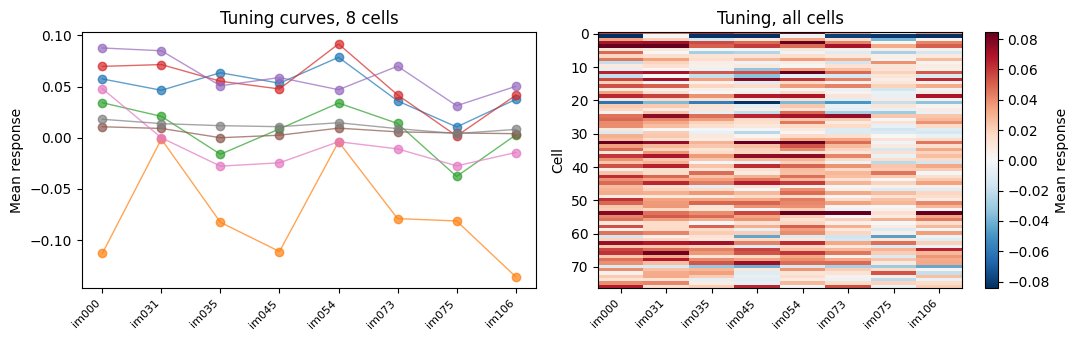

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for roi in range(min(8, condition_mean_response.shape[1])):
    axes[0].plot(range(len(conditions)), condition_mean_response[:, roi], marker='o', lw=1, alpha=0.7)
axes[0].set_ylabel('Mean response')
axes[0].set_title('Tuning curves, 8 cells')

color_limit = np.nanpercentile(np.abs(condition_mean_response), 98)
im = axes[1].imshow(condition_mean_response.T, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-color_limit, vmax=color_limit)
axes[1].set_ylabel('Cell')
axes[1].set_title('Tuning, all cells')
plt.colorbar(im, ax=axes[1], label='Mean response')

for ax in axes:
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** How many numbers make up one neuron's tuning curve?

That is how many paired observations each signal correlation gets. Write it down.

</div>

In [45]:
print('numbers per tuning curve:', condition_mean_response.shape[0])
print('trials available for noise correlations:', trial_response_matrix.shape[0])

numbers per tuning curve: 8
trials available for noise correlations: 4453


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: residuals &mdash; look before correlating</h3>

Subtract **each condition's own mean**, not the grand mean. Subtracting the grand mean would leave
the differences between conditions in the residuals, making your "noise" correlation partly a signal
correlation.

</div>

In [46]:
residuals = trial_response_matrix.copy().astype(float)

for c in conditions:
    mask = condition_labels == c
    residuals[mask] -= trial_response_matrix[mask].mean(axis=0)      # each chosen_condition's OWN mean

print('residuals shape:', residuals.shape)
print('mean of residuals (should be ~0):', round(float(residuals.mean()), 10))

residuals shape: (4453, 77)
mean of residuals (should be ~0): -5e-10


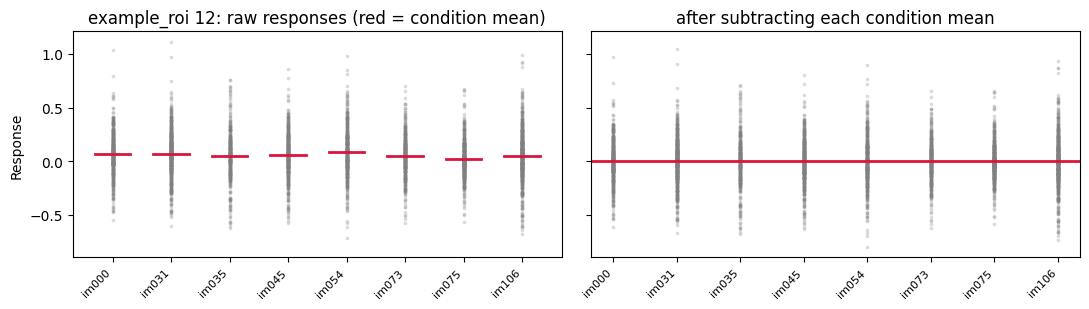

In [47]:
roi = example_roi          # the stimulus-modulated cell from Part 3

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)

for i, c in enumerate(conditions):
    axes[0].scatter(np.full((condition_labels == c).sum(), i), trial_response_matrix[condition_labels == c, roi],
                    s=3, alpha=0.2, color='gray')
    axes[0].plot([i - 0.3, i + 0.3], [condition_mean_response[i, roi]] * 2, color='crimson', lw=2)
axes[0].set_title(f'example_roi {roi}: raw responses (red = condition mean)')
axes[0].set_ylabel('Response')

for i, c in enumerate(conditions):
    axes[1].scatter(np.full((condition_labels == c).sum(), i), residuals[condition_labels == c, roi],
                    s=3, alpha=0.2, color='gray')
axes[1].axhline(0, color='crimson', lw=2)
axes[1].set_title('after subtracting each condition mean')

for ax in axes:
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: correlate</h3>

`np.corrcoef` correlates **rows**, so transpose to get cells rather than trials. Getting this
backwards produces a plausible matrix of entirely the wrong thing &mdash; check the output shape
against the number of cells.

</div>

In [48]:
signal_corr_matrix = np.corrcoef(condition_mean_response.T)         # (n_conditions, n_cells) -> cells
noise_corr_matrix = np.corrcoef(residuals.T)       # (n_trials, n_cells)     -> cells

pairs = np.triu_indices(signal_corr_matrix.shape[0], k=1)   # each pair once, no diagonal
signal_values = signal_corr_matrix[pairs]
noise_values = noise_corr_matrix[pairs]

print('cells:', signal_corr_matrix.shape[0], '-> unique pairs:', len(signal_values))
print(f'signal correlation: mean {np.nanmean(signal_values):+.4f}   '
      f'({condition_mean_response.shape[0]} observations per pair)')
print(f'noise  correlation: mean {np.nanmean(noise_values):+.4f}   '
      f'({residuals.shape[0]} observations per pair)')

cells: 77 -> unique pairs: 2926
signal correlation: mean +0.3247   (8 observations per pair)
noise  correlation: mean +0.1416   (4453 observations per pair)


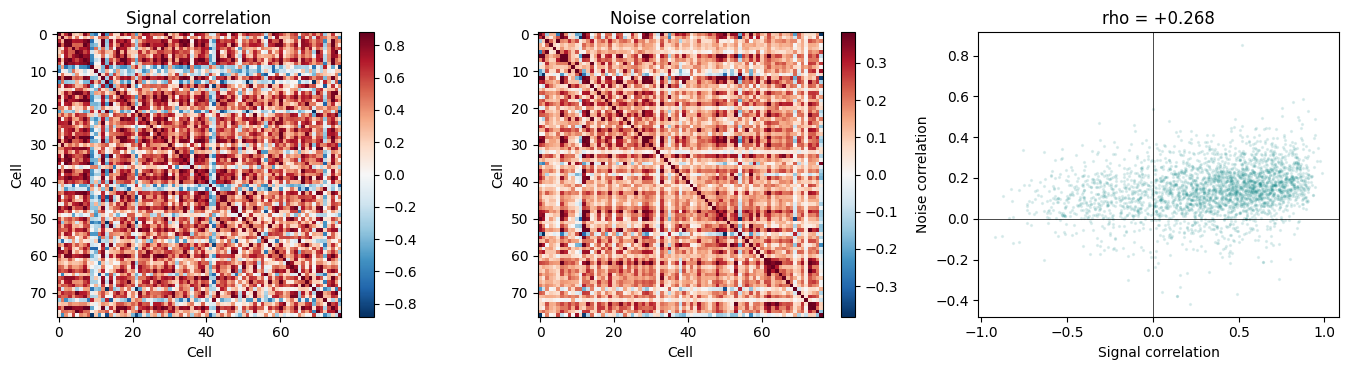

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for ax, C, label in [(axes[0], signal_corr_matrix, 'Signal correlation'),
                     (axes[1], noise_corr_matrix, 'Noise correlation')]:
    # scale each matrix to its own range so neither saturates
    off_diagonal = C[np.triu_indices(C.shape[0], k=1)]
    color_limit = np.nanpercentile(np.abs(off_diagonal), 98)
    im = ax.imshow(C, interpolation='nearest', cmap='RdBu_r', vmin=-color_limit, vmax=color_limit)
    ax.set_xlabel('Cell')
    ax.set_ylabel('Cell')
    ax.set_title(label)
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[2].scatter(signal_values, noise_values, s=2, alpha=0.1, color='teal')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].axvline(0, color='k', lw=0.5)
axes[2].set_xlabel('Signal correlation')
axes[2].set_ylabel('Noise correlation')

rho, p_value = stats.spearmanr(signal_values, noise_values, nan_policy='omit')
axes[2].set_title(f'rho = {rho:+.3f}')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Signal and noise correlations are positively related &mdash; the classic result. Neurons that
like the same stimuli also share their trial-to-trial fluctuations, found in essentially every
cortical area. It matters for coding, because shared noise aligned with the signal does not average
away as you add neurons.

Now compare the two matrices' **texture**, not their numbers. One has visible structure; the other is
closer to salt-and-pepper across the full range. That is what badly estimated correlations look
like &mdash; and both came from the same function on the same data.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. The single most useful check: **would you
get the same answer with half the data?**

Split trials in half at random, compute the correlations on each half separately, and correlate the
two halves' answers. Split **within each condition** so both halves see every condition.

Three outcomes, and all three are informative:

- **One high, one low** &mdash; trust the high one, and say why the other is not trustworthy.
- **Both high** &mdash; you have enough data for both; proceed.
- **Both near zero** &mdash; report that. It usually means the condition variable you chose does not
  organise these neurons' responses, however well-balanced it looked in the inventory. That is a
  real result about your dataset, and it is a better README than a matrix you cannot defend.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Before running it &mdash; which do you expect to be more reliable, signal or
noise correlations? Look back at the observation counts you wrote down.

</div>

In [50]:
def signal_and_noise_correlations(responses, labels):
    """Signal and noise correlation matrices from a set of trials.

    responses : (n_trials, n_cells) one response value per trial per cell
    labels    : (n_trials,) which condition each trial belongs to

    Signal correlation = do two cells prefer the same conditions?
    Noise correlation  = do two cells co-vary trial to trial WITHIN a
                         condition, once the condition mean is removed?
    """
    conditions = np.unique(labels)

    # TUNING: one row per condition, holding that condition's mean response for
    # every cell. Averaging over trials is what removes trial-to-trial noise
    # and leaves the stimulus preference -- the "signal".
    condition_means = np.vstack([responses[labels == c].mean(axis=0)
                                 for c in conditions])

    # RESIDUALS: each trial minus its own condition's mean. What remains is
    # everything the condition does NOT explain -- the "noise". Subtracting the
    # condition mean is essential: skip it and the condition structure leaks
    # into the noise matrix and inflates it.
    residuals = responses.astype(float).copy()
    for c in conditions:
        in_condition = labels == c
        residuals[in_condition] -= responses[in_condition].mean(axis=0)

    # .T because np.corrcoef correlates ROWS: we want cell-by-cell matrices,
    # and cells are the columns of both arrays.
    #
    # Note the very different sample sizes feeding these two matrices: signal
    # is estimated from len(conditions) numbers per cell, noise from
    # len(labels) trials. That asymmetry is why they differ so much in
    # reliability even though both render as equally convincing heatmaps.
    return np.corrcoef(condition_means.T), np.corrcoef(residuals.T)


In [51]:
rng = np.random.default_rng(0)
signal_reliability, noise_reliability = [], []

for _ in range(10):
    half_a, half_b = [], []
    for c in conditions:                       # split within each chosen_condition
        idx = rng.permutation(np.flatnonzero(condition_labels == c))
        h = len(idx) // 2
        half_a.append(idx[:h])
        half_b.append(idx[h:2 * h])
    a, b = np.concatenate(half_a), np.concatenate(half_b)

    Cs_a, Cn_a = signal_and_noise_correlations(trial_response_matrix[a], condition_labels[a])
    Cs_b, Cn_b = signal_and_noise_correlations(trial_response_matrix[b], condition_labels[b])

    signal_reliability.append(stats.spearmanr(Cs_a[pairs], Cs_b[pairs],
                                             nan_policy='omit').statistic)
    noise_reliability.append(stats.spearmanr(Cn_a[pairs], Cn_b[pairs],
                                            nan_policy='omit').statistic)

print('split-half reliability (agreement between two independent halves)')
print(f'  signal: {np.mean(signal_reliability):.3f} +/- {np.std(signal_reliability):.3f}')
print(f'  noise:  {np.mean(noise_reliability):.3f} +/- {np.std(noise_reliability):.3f}')

split-half reliability (agreement between two independent halves)
  signal: 0.414 +/- 0.039
  noise:  0.955 +/- 0.003


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

**This is the most important result in the notebook.**

Noise correlations reproduce well across independent halves (&asymp;0.93). Signal correlations
reproduce poorly (&asymp;0.16) &mdash; halve the data and you recover almost none of the structure.

The reason is the observation counts from Step 3. Each noise correlation comes from ~4400 trials; each
signal correlation comes from **8 numbers**, one per image. Correlating two 8-element vectors is noisy
no matter how many trials went into each entry.

Look back at the heatmaps. They are equally smooth and equally colorful. **Nothing in that figure
tells you one is far more trustworthy than the other.** You only know because you split the data.

<b>Report the number rather than working around it.</b> "Noise correlations were reliable (0.93);
signal correlations were not (0.16 over 8 conditions)" is a result you can defend. Sessions with more
conditions, or with fewer trials, land somewhere else entirely &mdash; the check is what tells you
which situation you are in.

Look back at the heatmaps. They are equally smooth and equally colorful. **Nothing in that figure
tells you one is far more trustworthy than the other.** You only know because you split the data.

The general lesson: the reliability of a correlation is set by the number of *observations being
correlated*, not the number of trials you collected. Count them, and report split-half reliability
alongside any correlation matrix you publish.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Does the signal you chose change the answer?</h3>

Everything so far used one representation of activity. If your dataset provides a second one, repeat
the whole chain on it and compare the numbers that matter. If it provides only one, note that and
move on.

To repeat the chain you need the response-matrix construction as a reusable function rather than a
one-off block &mdash; so wrap it, the same way you wrapped the correlations.

</div>

In [52]:
def trial_by_cell_responses(A):
    """Build the (n_trials, n_cells) baseline-subtracted response matrix.

    One number per trial per cell: mean activity in the response window minus
    mean activity in the baseline window. This is the matrix every correlation
    below is computed from, so the two window choices propagate into every
    result that follows.
    """
    response_rows = []
    for roi in range(A.shape[1]):
        # One cell at a time. pre/post are set from the window edges so the
        # returned window spans exactly baseline start to response end.
        w, t_w = align_to_event_times(A[:, roi], timestamps, all_onset_times,
                                 pre=-baseline_window[0], post=response_window[1])

        # Response minus baseline, per trial. Subtracting each trial's OWN
        # baseline removes slow drift in that cell across the session; a single
        # global baseline would leave the drift in the response.
        #
        # t_w < 0 excludes t = 0 itself, which is the first sample at/after the
        # event and therefore already contains post-stimulus time.
        response_rows.append(w[:, t_w >= 0].mean(axis=1) - w[:, t_w < 0].mean(axis=1))

    # .T because response_rows are cells here, and the matrix wants (trials, cells).
    return np.array(response_rows).T

def split_half_reliability(responses, labels, n_iter=10, seed=0):
    """How reproducible are the correlation matrices from independent trials?

    Splits the trials into two halves, computes the correlation matrices from
    each half separately, and asks how well the two agree. A high value means
    the structure is real; near zero means you are looking at noise.

    Returns (signal_reliability, noise_reliability) as Spearman correlations
    averaged over n_iter random splits.
    """
    rng = np.random.default_rng(seed)

    # Indices of the upper triangle, excluding the diagonal: the unique cell
    # pairs. Including the diagonal (always 1.0) would inflate the agreement.
    upper_triangle = np.triu_indices(responses.shape[1], k=1)

    signal_scores, noise_scores = [], []
    for _ in range(n_iter):
        half_a, half_b = [], []
        # Split WITHIN each condition, not across all trials at once, so both
        # halves see every condition. A blind split could leave a condition
        # entirely in one half, making its tuning undefined in the other.
        for c in np.unique(labels):
            idx = rng.permutation(np.flatnonzero(labels == c))
            n_half = len(idx) // 2
            if n_half < 1:
                continue                      # too few trials to split
            half_a.append(idx[:n_half])
            half_b.append(idx[n_half:2 * n_half])
        a, b = np.concatenate(half_a), np.concatenate(half_b)

        # Same computation on two disjoint trial sets.
        corr_a = signal_and_noise_correlations(responses[a], labels[a])
        corr_b = signal_and_noise_correlations(responses[b], labels[b])

        # Spearman rather than Pearson: we care whether the same PAIRS come out
        # ranked as most/least correlated, not whether values match exactly.
        signal_scores.append(stats.spearmanr(corr_a[0][upper_triangle],
                                             corr_b[0][upper_triangle],
                                             nan_policy='omit').statistic)
        noise_scores.append(stats.spearmanr(corr_a[1][upper_triangle],
                                            corr_b[1][upper_triangle],
                                            nan_policy='omit').statistic)
    return float(np.mean(signal_scores)), float(np.mean(noise_scores))


In [53]:
signals = [('dff', activity)]
if activity_events is not None:
    signals.append(('events', activity_events))

response_rows = []
for label, A in signals:
    R_sig = trial_by_cell_responses(A)
    labels_sig = labels[:R_sig.shape[0]]
    signal_corr, noise_corr = signal_and_noise_correlations(R_sig, labels_sig)
    upper_triangle = np.triu_indices(R_sig.shape[1], k=1)
    rel_signal, rel_noise = split_half_reliability(R_sig, labels_sig)

    response_rows.append({'signal_type': label,
                 'frac_zero_trials': round(float((R_sig == 0).mean()), 3),
                 'signal_mean': round(float(np.nanmean(signal_corr[upper_triangle])), 4),
                 'noise_mean': round(float(np.nanmean(noise_corr[upper_triangle])), 4),
                 'signal_reliability': round(rel_signal, 3),
                 'noise_reliability': round(rel_noise, 3)})

pd.DataFrame(response_rows)

,signal_type,frac_zero_trials,signal_mean,noise_mean,signal_reliability,noise_reliability
0,dff,0.000,0.3564,0.1420,0.530,0.954
1,events,0.436,0.2985,0.0861,0.676,0.864


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Every number moves, and one of them moves a lot.

Mean correlations are **smaller** on events, both signal and noise. Deconvolution removes the shared
slow fluorescence that inflates correlations between any two cells in the same field of view, so what
remains is closer to co-activation than to co-fluctuation of the baseline.

**Noise-correlation reliability drops substantially** on events &mdash; in our session from 0.93 to
0.73. Signal reliability, already poor, moves the other way (0.21 to 0.31): it is estimated from
8 condition means either way, so sparsity costs it much less than it costs the single-trial
residuals that noise correlations depend on. The `frac_zero_trials` column explains why: 49% of the single-trial event responses are exactly
zero, so a per-trial correlation rests on far fewer informative observations than the trial count
suggests.

**Signal-correlation reliability barely moves**, and if anything improves slightly
(0.21 to 0.31) &mdash; that asymmetry is the point.
Signal correlations average within a condition before correlating, so hundreds of mostly-zero trials
still produce a usable condition mean. Noise correlations work on the single trials themselves, where
the zeros are. Sparsity costs you exactly where you compute per trial. A correlation computed from mostly-zero vectors rests on far less
information than the trial count suggests, even though the trial count is identical.

That is the reliability lesson again in a new disguise. **Counting trials is not the same as counting
information.** Two analyses with the same number of trials can differ two-fold in how reproducible
their answers are.

Signal-correlation reliability stays poor for both, for the reason it was always poor: 8 conditions is
8 conditions regardless of which signal you feed it.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>One column may not be the whole condition.</b>

A column can look like a clean condition variable &mdash; many levels, perfectly balanced &mdash;
while the stimulus varied in some <i>other</i> way at the same time. Two trials sharing that column's
value are then not repeats of the same thing, and averaging them together destroys the tuning you
were trying to measure.

Receptive-field mapping is the classic case: orientation is balanced, but the stimulus also moves
around the screen, so "144 repeats of 45&deg;" is really a handful of repeats at each of many
positions. The same trap appears whenever a design crosses two factors and you only notice one.

Check for it by asking what else varies across the trials you just called identical. Group by your
condition column, look at the other columns within a group, and see whether they are constant. If
they are not, either restrict to one level of the other factor, or make the condition the
<i>combination</i> of both.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Signal correlations need a condition that repeats. Does your dataset have
one?

Inventory the candidate columns: how many distinct values, how many repeats, how balanced.

Then answer **two separate questions**, because they can disagree:

1. **Is the analysis possible?** Does some column have enough conditions with enough repeats?
2. **Is it meaningful?** Does that column label something you would expect neurons to be tuned
   *to*, in a way that a correlation across condition means would capture?

A column can pass the first test and fail the second. State a verdict on both, and check it against
your reliability numbers.

</div>

In [54]:
response_rows = []
for column in events.columns:
    values = events[column].dropna()
    if len(values) == 0:
        continue
    try:
        n_conditions = values.nunique()
    except TypeError:
        continue                        # unhashable column, e.g. arrays
    if not (2 <= n_conditions <= 60):
        continue
    counts = values.value_counts()
    response_rows.append({'column': column, 'n_conditions': int(n_conditions),
                 'min_reps': int(counts.min()), 'max_reps': int(counts.max()),
                 'balance': round(counts.min() / counts.max(), 2)})

pd.DataFrame(response_rows).sort_values('n_conditions', ascending=False)

,column,n_conditions,min_reps,max_reps,balance
3,HED,17,22,746,0.03
0,image_name,9,161,771,0.21
1,is_change,2,191,4614,0.04
2,omitted,2,161,4644,0.03


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Our example passes: **8 images** with roughly 450-700 presentations each, reasonably balanced.
Plenty of trials &mdash; but still only eight condition means, which is what limits the
signal-correlation reliability below.

Note what this check does *not* do: it reports any column with the right shape, so an ID column with
20 values would pass and be nonsense. **The code tells you whether the analysis is possible; only you
can tell whether it is sensible.**

Some datasets have no repeated conditions at all &mdash; a brain&ndash;computer-interface experiment
with spontaneous periods, photostimulation, and neurofeedback trials has nothing that repeats like a
grating. The inventory comes back negative and **that is a result, not a failure.** Do not invent a
condition variable to force the analysis. Ask instead what that dataset is unusually good for: noise
correlations need no conditions at all, and if single neurons were photostimulated, measuring how
others respond is far stronger evidence of coupling than any correlation.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Find out what is in the file** before analyzing it &mdash; and check that the dataset supports
   your question. Sometimes the answer is no.
2. **Plot the data after each transformation.** Single trials before averages; tuning curves before
   correlations.
3. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
4. **Try to break your own result.** Split the data in half and see if the answer survives.
5. **Let the dataset answer back.** If the check says your result is noise, or the dataset has no
   variable that supports your question, that is the finding. Report it rather than reaching for the
   analysis you planned to run.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| A well-balanced condition variable that means nothing | reliability, not the inventory |
| A condition column that hides a second varying factor | group by it, check what else moves |
| Analyzing units that should have been dropped | select on quality columns, and say so |
| A helper function silently drops data | compare output shape to input |
| A column exists but carries no information | check that it actually varies |
| One bad trial turns every cell's score into NaN | count your NaNs; use `nanmean` |
| Epoch comparisons confounded with time and behavior | check durations, order, behavior |
| An example cell chosen to look good | state your selection rule |
| Data looks absent but is stored elsewhere | look in every container first |
| An index from an earlier cell after reshaping the data | re-derive indices, never carry them |

<h3>Why this matters</h3>

You can generate an analysis faster than you can validate one. The only defense is to know your data
well enough that a wrong answer looks wrong to **you** &mdash; because it will not look wrong to the
code, and it will not look wrong on the plot.

</div>